In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import math
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from torch.utils.data import Dataset, TensorDataset, DataLoader, ConcatDataset
from typing import Optional, Callable, Dict
from tqdm.notebook import tqdm, trange
from torchvision import datasets, transforms
import numpy as np
import plotly.express as px
import random
import glob
import re
import torchvision
import lpips
from transformers import CLIPTextModel, CLIPTokenizer
import json
import urllib.request
import os
import time
from pathlib import Path
from PIL import Image, ImageOps
from torchmetrics.image.fid import FrechetInceptionDistance
import matplotlib.pyplot as plt
from torchsummary import summary
import cv2
import shutil
import clip

For debugging and reproducibility I fix the seeds, removing the stochastic randomness component.
Then, if I have NVIDIA GPUs I use CUDA; if I have Apple Silicon I use MPS ([Metal Performance Shaders](https://en.wikipedia.org/wiki/Metal_(API))). If none of the previous 2 are possible I resort to CPU.

In [ ]:
def set_seed(seed: int = 0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(0)
device = torch.device("cpu")
if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.backends.cudnn.benchmark = True
elif torch.backends.mps.is_available():
    device = torch.device("mps")
print("device:", device)

T = 1000
test = True

## Initial dataset and data loader
To generate my data (points on a circle) I sample the angle $\theta$ from a uniform over $[0,2\pi]$ and use polar coordinates with a radius $r$:
- $x = r\cdot cos(\theta)$
- $y = r\cdot sin(\theta)$

The DataLoader will shuffle my data at the beginning of each epoch, divide them into batches and make them an iterator. As an input it needs an object implementing Dataset interface (which has the methods to get the total count of my data and to extract a specific record): this is done by TensorDataset which is an adapter of the tensor returned by my `generate_circles` method

In [ ]:
def generate_circles(num_samples=5000, radius=2.0):
    theta = torch.rand(num_samples) * 2 * math.pi
    x = radius * torch.cos(theta)
    y = radius * torch.sin(theta)
    return torch.stack((x, y), dim=-1)

circles = generate_circles(num_samples=10000)
train_dl = DataLoader(TensorDataset(circles), batch_size=64, shuffle=True) 

## First network: unconditional score Multi-Layer Perceptron
My first network is a MLP that is composed of fully connected layers (`nn.Linear`). For convenience and code readability I implemented a for loop adding linear layers + activation, even if with any number of hidden layer my full architecture will initially have 2 consecutive linear layers (two linear transformations collapse into one linear transformation). My last layer is still linear since I want to get 2-dimensional tensors having values on all $\mathbb{R}$ (yeah, apart digit approximation of course)

- Input: a point $(x,y)$; 
- Output: the predicted noise $(\epsilon_x, \epsilon_y)$

From the predicted noise I'm defining a direction because when we subtract it we move closer to the clean data. 

In [ ]:
class ScoreMLPPoints(nn.Module):
    def __init__(self, num_layers: int, hidden_dim: int, 
                 activation: Callable[[torch.Tensor], torch.Tensor]) -> None:
        super().__init__()
        self.first_layer = nn.Linear(in_features=2, out_features=hidden_dim)
        self.layers = nn.ModuleList()
        for _ in range(num_layers):
            self.layers.append(
                nn.Linear(in_features=hidden_dim, out_features=hidden_dim)
            )
        self.activation = activation
        self.last_layer = nn.Linear(in_features=hidden_dim, out_features=2)

    def forward(self, meshgrid: torch.Tensor) -> torch.Tensor:
        out = meshgrid
        out = self.first_layer(out)
        for layer in self.layers:
            out = layer(out)
            out = self.activation(out)
        out = self.last_layer(out)
        return out

In [ ]:
def plot_2d_points(points, title, color):
    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=points[:, 0], y=points[:, 1],
            mode='markers',
            marker=dict(size=4, color=color, opacity=0.6),
            name=title
        )
    )
    fig.update_layout(
        title=title, 
        width= 800,
        height= 800,
        xaxis=dict(range=[-6, 6]), 
        yaxis=dict(range=[-6, 6])
    )
    fig.show()

Training parameters

In [ ]:
num_layers = 3
hidden_dim = 128
sigma = 0.3
epochs = 6 if not test else 1#50

## Model instantiation, activation and optimizer
For the activation function, in the course we've seen some ("relu", "leaky_relu", "elu", "sigmoid",  "tanh"). I would avoid `sigmoid` and `tanh` for vanishing gradient problem. In the following plots I'll see how each of them behaves for this task.

In [ ]:
model = ScoreMLPPoints(num_layers=num_layers, 
                       hidden_dim=hidden_dim, 
                       activation=torch.nn.functional.relu)

In [ ]:
from torchinfo import summary
summary(model, input_size=(64, 2))

I use Adam optimizer because it's fast and robust: it updates weights based on the moving average of past gradients allowing the model to escape local minima; it stabilizes unstable parameters.

Then in each epoch after extracting a batch of data I add noise and try to predict that noise. I compute the MSE loss, compute the gradients with backpropagation, update the weights and zero out the gradients to avoid they accumulate.

In [ ]:
model = model.to(device)
opt = optim.Adam(model.parameters(), lr=0.001)
def training(model, epochs, sigma):
    for epoch in tqdm(range(epochs), desc="epoch"):
        model.train()
        epoch_loss = 0.0 
        num_batches = 0  
        for (xbatch,) in train_dl:
            x_orig = xbatch.to(device)
            noise = torch.randn_like(x_orig)
            x_noisy = x_orig + sigma * noise
            noise_predicted = model(x_noisy)
            loss = F.mse_loss(noise_predicted, noise)
            loss.backward()
            opt.step()
            opt.zero_grad()
            epoch_loss += loss.item()
            num_batches += 1
        print(epoch, epoch_loss / num_batches)
training(model, epochs, sigma)

Now I try to create new points from Gaussian noise scaled to increase the spread of points. I don't need to compute gradients here.

I implement Langevin dynamics `x_langevin` from the following equation
$$\tilde{\mathbf{x}}^k = \tilde{\mathbf{x}}^{k-1} + \frac{\lambda_i}{2} \mathbf{s}_\theta(\tilde{\mathbf{x}}^{k-1}, \sigma_i) + \sqrt{\lambda_i}\mathbf{z}^k$$


where at each step $k$ I update the previous position $\tilde{\mathbf{x}}^{k-1}$ moving along the direction of the score with a step length scaled by a fixed $\lambda_i$. A standard Gaussian vector $\mathbf{z}^k$ adds randomness to explore the space.


In [ ]:
model.eval()
num_steps = 300
lambda_i = 0.01
sd_scaling = 2.0
x_langevin = torch.randn(1000, 2, device=device) * sd_scaling
noise0 = x_langevin.cpu()
snapshots = {}
monitored_steps = [1, 10, 20, 50, 100, 300]
def generated_data(num_steps, model, x_langevin, snapshots):
    with torch.no_grad():
        for k in range(num_steps):
            pred_noise = model(x_langevin)
            #Delta_x log(p(x)), I move towards the real data
            score = - pred_noise / sigma
            z = torch.randn_like(x_langevin)
            x_langevin =  x_langevin + lambda_i/2 * score + math.sqrt(lambda_i) * z
            current_step = k + 1
            if current_step in monitored_steps:
                snapshots[current_step] = x_langevin.cpu()
    generated_points = x_langevin.cpu()
    return generated_points

generated_points = generated_data(num_steps, model, x_langevin, snapshots)


In [ ]:
#visualization
plot_2d_points(circles.cpu(), "Original data", "lightgreen")
plot_2d_points(noise0, "Initial noise", "red")
plot_2d_points(generated_points, "Data generated", "orange")

With `relu` activation function.

In [ ]:
model = ScoreMLPPoints(num_layers=num_layers, 
                       hidden_dim=hidden_dim, 
                       activation=torch.nn.functional.relu)
model = model.to(device)
opt = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
training(model, epochs, sigma)

Given the equations in the pdf I can get the score as a function of the noise.


- $\nabla_{\tilde{\mathbf{x}}} \log q_\sigma(\tilde{\mathbf{x}} \mid \mathbf{x}) = \dfrac{\mathbf{x} - \tilde{\mathbf{x}}}{\sigma^2}$


- $\tilde{\mathbf{x}} = \mathbf{x} + \sigma \epsilon \implies \mathbf{x} - \tilde{\mathbf{x}} = -\sigma \epsilon$


Here:
* **$\mathbf{x}$** is the original data
* **$\tilde{\mathbf{x}}$** represents noisy data
* **$\sigma$** is the SD of the Gaussian noise
* **$\epsilon$** is the standard Gaussian noise vector that will dirty my data
* **$q_\sigma(\tilde{\mathbf{x}} \mid \mathbf{x})$** is the conditional probability distribution of the noisy data given the clean data and will model the noise corruption process.
* **$\nabla_{\tilde{\mathbf{x}}}$**: the gradient is computed wrt the noisy data and provides the direction of change

I use the same Langevin dynamics that I defined before

In the end I get
$$\nabla_{\tilde{\mathbf{x}}} \log q_\sigma(\tilde{\mathbf{x}} \mid \mathbf{x}) = \frac{-\sigma \epsilon}{\sigma^2} = -\frac{\epsilon}{\sigma}$$

In [ ]:
model.eval()
num_steps = 300
step_size = 0.01 
x_langevin = torch.randn(1000, 2, device=device) * 4.0
noise0 = x_langevin.cpu()
snapshots = {}
monitored_steps = [1, 10, 20, 50, 100, 300]
generated_points = generated_data(num_steps, model, x_langevin, snapshots)

In [ ]:
circles = circles.cpu()

plot_2d_points(circles, "Original data", "lightgreen")
plot_2d_points(noise0, "Noise", "red")
plot_2d_points(generated_points, "Data generated", "orange")

## With ELU for more epochs

In [ ]:
num_layers = 3
hidden_dim = 128
sigma = 0.3
epochs = 30 if not test else 1
model = ScoreMLPPoints(num_layers=num_layers, 
                       hidden_dim=hidden_dim, 
                       activation=torch.nn.functional.elu)
model = model.to(device)
opt = optim.Adam(model.parameters(), lr=0.001)
training(model, epochs, sigma)
model.eval()
num_steps = 300
step_size = 0.01 
x_langevin = torch.randn(1000, 2, device=device) * 4.0
noise0 = x_langevin.cpu().clone()
snapshots = {}
monitored_steps = [1, 10, 20, 50, 100, 300]
generated_points = generated_data(num_steps, model, x_langevin, snapshots)

circles = circles.cpu()

plot_2d_points(circles, "Original data", "lightgreen")
plot_2d_points(noise0, "Noise", "red")
plot_2d_points(generated_points, "Data generated", "orange")

Here I plot some steps of my data generation process

In [ ]:
plot_2d_points(noise0, "Initial noise", "red")
for step in monitored_steps:
    plot_2d_points(
        snapshots[step],
        title=f"Step {step}: Inversion Process",
        color="orange"
    )

In [ ]:
#better to represent them in a grid
all_steps = monitored_steps
titles = [f"Step {step}" for step in all_steps]
fig = make_subplots(rows=2, cols=3, subplot_titles=titles)
for idx, step in enumerate(all_steps):
    row = (idx // 3) + 1
    col = (idx % 3) + 1
    points = noise0 if step == 0 else snapshots[step]
    fig.add_trace(
        go.Scatter(
            x=points[:, 0], y=points[:, 1],
            mode='markers',
            marker=dict(size=3, color="orange", opacity=0.6),
            showlegend=False
        ),
        row=row, col=col
    )
    fig.update_layout(
        width= 900, height = 900
    )   
fig.update_xaxes(range=[-6, 6])
fig.update_yaxes(range=[-6, 6])
fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.show()

## Comparison of activations

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import math

activation_dict = {
    "ReLU": F.relu,
    "LeakyReLU": F.leaky_relu,
    "ELU": F.elu,
    "Sigmoid": torch.sigmoid,
    "Tanh": torch.tanh
}

num_layers = 3
hidden_dim = 128
sigma = 0.3
epochs = 30 if not test else 1
num_steps = 30#300
step_size = 0.01
monitored_steps = [20,22,24,26,28,30]#[1, 10, 20, 50, 100, 300]
results_archive = {}

for act_name, act_fn in activation_dict.items():
    print(f"Start training for {act_name}")
    model = ScoreMLPPoints(num_layers=num_layers, hidden_dim=hidden_dim, activation=act_fn).to(device)
    opt = optim.Adam(model.parameters(), lr=0.001)
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0 
        num_batches = 0  
        for (xb,) in train_dl:
            x_orig = xb.to(device)
            noise = torch.randn_like(x_orig)
            x_noisy = x_orig + sigma * noise
            noise_predicted = model(x_noisy)
            loss = F.mse_loss(noise_predicted, noise)
            loss.backward()
            opt.step()
            opt.zero_grad()
            epoch_loss += loss.item()
            num_batches += 1
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoca {epoch+1:02d}/{epochs} | Loss Media: {epoch_loss / num_batches:.5f}")
            
    model.eval()
    x_langevin = torch.randn(1000, 2, device=device) * 4.0
    snapshots = {}
    with torch.no_grad():
        for k in range(num_steps):
            pred_noise = model(x_langevin)
            score = - pred_noise / sigma
            
            z = torch.randn_like(x_langevin)
            x_langevin = x_langevin + 0.5 * step_size * score + math.sqrt(step_size) * z
            
            current_step = k + 1
            if current_step in monitored_steps:
                snapshots[current_step] = x_langevin.cpu().numpy()
                
    results_archive[act_name] = snapshots

print("Final plot")

subplot_titles = []
for act_name in activation_dict.keys():
    for step in monitored_steps:
        subplot_titles.append(f"{act_name} (Step {step})")
        
fig = make_subplots(
    rows=len(activation_dict), 
    cols=len(monitored_steps), 
    subplot_titles=subplot_titles,
    vertical_spacing=0.06,
    horizontal_spacing=0.04
)
for row_idx, act_name in enumerate(activation_dict.keys()):
    snapshots = results_archive[act_name]
    for col_idx, step in enumerate(monitored_steps):
        points = snapshots[step]
        colors = ["red", "orange", "green", "blue", "purple"]
        current_color = colors[row_idx]
        fig.add_trace(
            go.Scatter(
                x=points[:, 0], y=points[:, 1],
                mode='markers',
                marker=dict(size=2, color=current_color, opacity=0.5),
                showlegend=False
            ),
            row=row_idx + 1, col=col_idx + 1
        )

fig.update_xaxes(range=[-6, 6])
fig.update_yaxes(range=[-6, 6])
fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.update_layout(
    title_text=f"Activation comparison, {epochs} train epochs",
    title_x=0.5,
    width=1400, 
    height=1200
)

fig.show()

Looking at the plots of the first 30 steps for the different activation I decided to use RELU because it achieved the best overall quality.

Let's see if it generalizes: let's generate sinusoids

In [ ]:
def sines(num_samples=5000, amp=1.0, freq=1.0):
    theta = torch.rand(num_samples) * 2 * math.pi
    y = amp * torch.sin(freq * theta)
    return torch.stack((theta, y), dim=-1)

x_clean_sine = sines(num_samples=10000)
print(x_clean_sine.shape) 
train_ds_sine = TensorDataset(x_clean_sine)
train_dl_sine = DataLoader(train_ds_sine, batch_size=64, shuffle=True) 

In [ ]:
model = ScoreMLPPoints(num_layers=3, hidden_dim=128, activation=torch.nn.functional.elu)
model = model.to(device)
opt = optim.Adam(model.parameters(), lr=0.001)
sigma = 0.3
epochs = 21 if not test else 1
losses_h = []
for epoch in tqdm(range(epochs), desc="epoch"):
    model.train()
    epoch_loss = 0.0 
    num_batches = 0  
    for (xb,) in train_dl_sine:
        x_clean = xb.to(device)
        noise = torch.randn_like(x_clean)
        x_noisy = x_clean + sigma * noise
        pred_noise = model(x_noisy)
        loss = F.mse_loss(pred_noise, noise)
        loss.backward()
        opt.step()
        opt.zero_grad()
        epoch_loss += loss.item()
        num_batches += 1
    mean_epoch_loss = epoch_loss / num_batches
    losses_h.append(mean_epoch_loss)
    print(epoch, mean_epoch_loss)
   
min_loss_index = losses_h.index(min(losses_h))
print(f"Minimum loss of {losses_h[min_loss_index]:.6f} at epoch {min_loss_index}")
loss_fig = go.Figure()
loss_fig.add_trace(
    go.Scatter(
        x=list(range(epochs)),
        y=losses_h,
        mode='lines+markers',
        name='MSE Loss',
        line=dict(color='deepskyblue', width=2)
    )
)
loss_fig.update_layout(
    title="Training Loss",
    xaxis_title="Epoch",
    yaxis_title="MSE Loss"
)
loss_fig.show()

# langevin sampling with snapshots
model.eval()
num_steps = 1000
step_size = 0.01 
x_langevin = torch.randn(1000, 2, device=device) * 4.0
initial_noise_np = x_langevin.cpu().clone().numpy()
snapshots = {}
monitored_steps = [1, 10, 20, 50, 100, 300, 500, 1000]
with torch.no_grad():
    for k in range(num_steps):
        pred_noise = model(x_langevin)
        score = - pred_noise / sigma
        # langevin dynamics step
        z = torch.randn_like(x_langevin)
        x_langevin = x_langevin + 0.5 * step_size * score + math.sqrt(step_size) * z
        current_step = k + 1
        if current_step in monitored_steps:
            snapshots[current_step] = x_langevin.cpu().numpy()

final_generated_np = x_langevin.cpu().numpy()
all_steps =  monitored_steps
titles = [f"Step {step}" for step in all_steps]
fig = make_subplots(rows=2, cols=4, subplot_titles=titles)
for idx, step in enumerate(all_steps):
    row = (idx // 4) + 1
    col = (idx % 4) + 1
    points = initial_noise_np if step == 0 else snapshots[step]
    fig.add_trace(
        go.Scatter(
            x=points[:, 0], y=points[:, 1],
            mode='markers',
            marker=dict(size=3, color="orange", opacity=0.6),
            showlegend=False
        ),
        row=row, col=col
    )

fig.update_xaxes(range=[-6, 6])
fig.update_yaxes(range=[-6, 6])
fig.show()

## With different values of $\sigma$

In [ ]:
## see torch.nn.functional.elu vs F.elu
sigmas = [0.1, 0.3, 0.8]
epochs = 21 if not test else 1
my_models = {}
my_losses = {}
def energy(y_pred, y_true):
    return torch.nn.functional.mse_loss(y_pred, y_true)
for sigma in sigmas:
    print(f"Test with sigma {sigma} ")
    # init
    model = ScoreMLPPoints(num_layers=3, hidden_dim=128, activation=torch.nn.functional.elu )
    model = model.to(device)
    opt = optim.Adam(model.parameters(), lr=0.001)
    losses_h = []
    # training
    for epoch in tqdm(range(epochs), desc=f"Training with sigma {sigma}"):
        model.train()
        epoch_loss = 0.0
        samples_nr = 0
        for (xb,) in train_dl_sine:
            x_clean = xb.to(device)
            noise = torch.randn_like(x_clean)
            x_noisy = x_clean + sigma * noise
            pred_noise = model(x_noisy)
            loss = energy(pred_noise, noise)
            loss.backward()
            opt.step()
            opt.zero_grad()
            epoch_loss += loss.item() * len(x_clean)
            samples_nr += len(x_clean)
        mean_epoch_loss = epoch_loss / samples_nr
        losses_h.append(mean_epoch_loss)
    my_models[sigma] = model.state_dict()
    my_losses[sigma] = losses_h
    min_loss_idx = losses_h.index(min(losses_h))
    print(f"[Sigma {sigma}] min loss {losses_h[min_loss_idx]:.6f} at epoch {min_loss_idx}")
    
    loss_fig = go.Figure()
    loss_fig.add_trace(
        go.Scatter(
            x=list(range(epochs)),
            y=losses_h,
            mode='lines+markers',
            name=f'MSE Loss (sigma={sigma})',
            line=dict(color='deepskyblue', width=2)
        )
    )
    loss_fig.update_layout(
        title=f"Training Loss Curve (Sigma = {sigma})",
        xaxis_title="Epoch", yaxis_title="MSE Loss"
    )
    loss_fig.show()

    model.eval()
    num_steps = 1000
    step_size = 0.01
    x_langevin = torch.randn(1000, 2, device=device) * 4.0
    snapshots = {}
    monitored_steps = [1, 10, 20, 50, 100, 300, 500, 1000]
    with torch.no_grad():
        for k in range(num_steps):
            pred_noise = model(x_langevin)
            score = - pred_noise / sigma
            z = torch.randn_like(x_langevin)
            x_langevin = x_langevin + 0.5 * step_size * score + math.sqrt(step_size) * z
            current_step = k + 1
            if current_step in monitored_steps:
                snapshots[current_step] = x_langevin.cpu().numpy()
    all_steps = monitored_steps
    titles = [f"Step {step}" for step in all_steps]
    grid_fig = make_subplots(rows=2, cols=4, subplot_titles=titles)
    for idx, step in enumerate(all_steps):
        row = (idx // 4) + 1
        col = (idx % 4) + 1
        points = snapshots[step]
        grid_fig.add_trace(
            go.Scatter(
                x=points[:, 0], y=points[:, 1],
                mode='markers',
                marker=dict(size=3, color="orange", opacity=0.6),
                showlegend=False
            ),
            row=row, col=col
        )
    grid_fig.update_layout(
        title_text=f"Langevin Inversion Grid (Sigma = {sigma})"
    )
    grid_fig.update_xaxes(range=[-6, 6])
    grid_fig.update_yaxes(range=[-6, 6])
    grid_fig.show()

## Let's go NCSNs!
Since basic score estimation is unreliable in low density regions now we're conditioning on $\sigma$ instead of having it fixed. Then I use Langevin dynamics running a schedule to decrease sigma progressively.

This new architecture adds just a linear layer for the input sigma and combines its embedding to the coordinate embeddings. The rest is the same.

In [ ]:
#qui
class CondMLPFirstV(nn.Module):
    def __init__(self,
                num_layers: int,
                hidden_dim: int,
                activation: Callable[[torch.Tensor], torch.Tensor]) -> None:
        super().__init__()
        self.first_layer = nn.Linear(in_features=2, out_features=hidden_dim)
        self.sigma_l1 = nn.Linear(in_features=1, out_features=hidden_dim)
        self.layers = nn.ModuleList()
        for _ in range(num_layers):
            self.layers.append(
                nn.Linear(in_features=hidden_dim, out_features=hidden_dim)
            )
        self.activation = activation
        self.last_layer = nn.Linear(in_features=hidden_dim, out_features=2)
    def forward(self, meshgrid: torch.Tensor, sigma: torch.Tensor) -> torch.Tensor:
        out = meshgrid
        out = self.first_layer(out)
        sigma_embedding = self.sigma_l1(sigma)
        out += sigma_embedding
        out = self.activation(out)
        for layer in self.layers:
            out = layer(out)
            out = self.activation(out)
        out = self.last_layer(out)
        return out

Now my inputs are the sinusoids' points (theta, y) and the sigmas. To get the summary I'll use a batch_size = 64.

In [ ]:
#noise schedule
L = 8 
sigma_max = 4.0
sigma_min = 0.05
sigmas = torch.exp(torch.linspace(math.log(sigma_max), math.log(sigma_min), L)).to(device)
model = CondMLPFirstV(num_layers=3, hidden_dim=128, activation=torch.nn.functional.relu).to(device)
summary(model, input_size=[(64,2), ((64,1))])

In [ ]:
model = model.to(device)
opt = optim.Adam(model.parameters(), lr=0.001)
epochs = 30 if not test else 1
losses_h = []
#training
for epoch in tqdm(range(epochs), desc="Training NCSN"):
    model.train()
    epoch_loss = 0.0 
    samples_nr = 0  
    for (xb,) in train_dl_sine:
        x_clean = xb.to(device)
        batch_size = x_clean.shape[0]
        indices = torch.randint(0, L, (batch_size,), device=device)
        batch_sigmas = sigmas[indices].view(-1, 1)
        noise = torch.randn_like(x_clean)
        x_noisy = x_clean + batch_sigmas * noise
        pred_noise = model(x_noisy, batch_sigmas)
        loss = F.mse_loss(pred_noise, noise)
        loss.backward()
        opt.step()
        opt.zero_grad()
        epoch_loss += loss.item() * len(x_clean)
        samples_nr += len(x_clean)
    losses_h.append(epoch_loss / samples_nr)
print(f"Final loss: {losses_h[-1]:.6f}")

In [ ]:
model.eval()
steps_per_scale = 125
epsilon = 0.005      
x_langevin = torch.randn(1000, 2, device=device) * sigmas[0]
snapshots = {}
snapshot_titles = []
with torch.no_grad():
    for i, sig in enumerate(sigmas):
        step_size = epsilon * (sig / sigmas[-1])**2
        for k in range(steps_per_scale):
            batch_sig = torch.full((1000, 1), sig.item(), device=device)
            pred_noise = model(x_langevin, batch_sig)
            score = -pred_noise / sig
            z = torch.randn_like(x_langevin)
            x_langevin = x_langevin + 0.5 * step_size * score + math.sqrt(step_size) * z
        title = f"Scale {i+1} (s={sig:.2f})"
        snapshots[title] = x_langevin.cpu().numpy()
        snapshot_titles.append(title)#viz
fig = make_subplots(rows=2, cols=4, subplot_titles=snapshot_titles)
for idx, (title, points) in enumerate(snapshots.items()):
    row = (idx // 4) + 1
    col = (idx % 4) + 1
    fig.add_trace(
        go.Scatter(
            x=points[:, 0], y=points[:, 1],
            mode='markers',
            marker=dict(size=3, color="orange", opacity=0.6),
            showlegend=False
        ),
        row=row, col=col
    )
fig.update_layout(title_text="NCSN V1")
fig.update_xaxes(range=[-6, 6])
fig.update_yaxes(range=[-6, 6])
fig.show()

## Diffusion Probabilistic Models

DPMs are based on a Markov Chain made by a sequence of states. Starting from a clean sample taken from the true distribution the forward process adds Gaussian noise for $T=1000$ steps. The main properties of MC is that the future is independent from the past given the present and in this case the final state will be a standard Gaussian distribution (pure noise).
Data generation is allowed by reverting this process: starting from random noise an update rule iteratively denoise it untill we get to new data. In each transition some random noise is added to explore the space of the data.
Since the network has no information on the temporal progression and a simple discrete integer timestep won't add much expressivity, that same timestep is transformed into sines and cosines, continuous functions with good properties as we will see.

## SinusoidalPositionEmbeddings




As we've seen in transformers architectures tokens are processed in parallel, so order is not tracked. Sentences as "Luca slaps Giovanni" and "Giovanni slaps Luca" are considered the same. In the paper "Attention is all you need" to track token order positional encodings (PEs) are injected into the encoder and decoder adding them to the input embeddings. PEs are implemented from sine and cosine functions with different frequencies. They have good properties: since they're boundend in $[-1, 1]$ they avoid numerical explosion; being periodical they can manage variable length sequences; the token relative distance is constant either if I consider tokens 1-2 or 2000-2001


- $PE_{(t,\, 2i)} = \sin\left(\frac{t}{10000^{\frac{2i}{d_m}}}\right)$


- $PE_{(t,\, 2i+1)} = \cos\left(\frac{t}{10000^{\frac{2i}{d_m}}}\right)$


where $t$ is the token time/position in the sequence and $d_m$ is the embedding space dimension.


*Sources*
- [Attention is all you need](https://arxiv.org/pdf/1706.03762)
- [Sinusoidal positional encodings](https://medium.com/@pranay.janupalli/understanding-sinusoidal-positional-encoding-in-transformers-26c4c161b7cc)

In [ ]:
beta_start = 1e-4
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end, T).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sigmas = torch.sqrt(betas)

def make_averager():
    count = 0
    total = 0
    def averager(new_value):
        nonlocal count, total
        if new_value is None:
            return total / count if count else float("nan")
        count += 1
        total += new_value
        return total / count
    return averager

def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_a_bar_t = torch.sqrt(alphas_cumprod[t]).unsqueeze(-1)
    sqrt_one_minus_a_bar_t = torch.sqrt(1. - alphas_cumprod[t]).unsqueeze(-1)
    return sqrt_a_bar_t * x0 + sqrt_one_minus_a_bar_t * noise

Thanks to logarithm properties

$$\begin{aligned}
\text{inv\_freq}_i &= \exp\left( \text{indices} \times - \frac{\ln(10000)}{M - 1} \right) \\
&= \exp\left( -\frac{i \cdot \ln(10000)}{M - 1} \right) \\
&= \exp\left( \ln(10000) \cdot \left(-\frac{i}{M - 1}\right) \right) \\
&= \left( e^{\ln(10000)} \right)^{-\frac{i}{M - 1}} \\
&= 10000^{-\frac{i}{M - 1}} \\
&= \frac{1}{10000^{\frac{i}{M - 1}}} \\
\implies \text{args}_{t,i} &= t \times \text{inv\_freq}_i = \frac{t}{10000^{\frac{i}{M - 1}}}
\end{aligned}$$

In [ ]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim
    def forward(self, time: torch.Tensor) -> torch.Tensor:
        half_dim = self.dim // 2
        inv_freq = torch.exp(torch.arange(half_dim, device=time.device) * -math.log(10000) / (half_dim - 1))
        args = time[:, None] * inv_freq[None, :]
        args = torch.cat((args.sin(), args.cos()), dim=-1)
        return args

In [ ]:
class TimeEmbedding(nn.Module):
    def __init__(self, hidden_dim: int, activation: Callable):
        super().__init__()
        self.emb = SinusoidalPositionEmbeddings(hidden_dim)
        self.fc1 = nn.Linear(hidden_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.activation = activation
        
    def forward(self, time):
        h = self.emb(time)
        h = self.activation(self.fc1(h))
        return self.fc2(h)
    
class DPM(nn.Module):
    def __init__(self, num_layers: int, hidden_dim: int, activation: Callable):
        super().__init__()
        self.first_layer = nn.Linear(2, hidden_dim)
        self.time_mlp = TimeEmbedding(hidden_dim, activation)
        self.layers = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim) for _ in range(num_layers)
        ])
        self.activation = activation
        self.last_layer = nn.Linear(hidden_dim, 2)
        
    def forward(self, x, time):
        h = self.activation(self.first_layer(x) + self.time_mlp(time))
        for layer in self.layers:
            h = layer(h)
            h = self.activation(h)
        return self.last_layer(h)

In [ ]:
model = DPM(num_layers=3, hidden_dim=128, activation=torch.nn.functional.elu).to(device)
opt = optim.Adam(model.parameters(), lr=0.001)
epochs = 40 if not test else 1
losses_h = []

for epoch in trange(epochs, desc="train epoch"):
    model.train()
    train_loss_averager = make_averager() 
    tqdm_iterator = tqdm(
        enumerate(train_dl_sine),
        total=len(train_dl_sine),
        desc="batch [loss: None]",
        leave=False,
    )
    for batch_idx, (xb,) in tqdm_iterator:
        x_clean = xb.to(device)
        batch_size = x_clean.shape[0]
        t = torch.randint(0, T, (batch_size,), device=device).long()
        noise = torch.randn_like(x_clean)
        x_noisy = q_sample(x_clean, t, noise)
        pred_noise = model(x_noisy, t.float())
        loss = F.mse_loss(pred_noise, noise)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss_averager(loss.item())
        tqdm_iterator.set_description(
            f"train batch [avg loss: {train_loss_averager(None):.3f}]"
        )
        tqdm_iterator.refresh()
        
    losses_h.append(train_loss_averager(None))
    print(
        f"Epoch: {epoch}\n"
        f"Train set: Average loss: {train_loss_averager(None):.4f}\n"
    )

print(f"Final Loss for DPM : {losses_h[-1]:.6f}")

In [ ]:
# I start from random noise and run the reverse diffusion process to generate samples
model.eval()
x_trajectory = torch.randn(1000, 2, device=device)
initial_noise_np = x_trajectory.cpu().numpy()

snapshots = {}
monitored_timesteps = [999, 700, 500, 300, 100, 50, 20, 0]

with torch.no_grad():
    for t_idx in reversed(range(T)):
        t_batch = torch.full((1000,), t_idx, device=device, dtype=torch.float)
        pred_noise = model(x_trajectory, t_batch)
        beta_t = betas[t_idx]
        alpha_t = alphas[t_idx]
        alpha_cumprod_t = alphas_cumprod[t_idx]
        #reparameterized mu
        mean_coef = 1.0 / torch.sqrt(alpha_t)
        noise_coef = beta_t / torch.sqrt(1.0 - alpha_cumprod_t)
        model_mean = mean_coef * (x_trajectory - noise_coef * pred_noise)
        #update step: noise added to all steps except the last one
        if t_idx > 0:
            z = torch.randn_like(x_trajectory)
            sigma_t = sigmas[t_idx]
            x_trajectory = model_mean + sigma_t * z
        else:
            x_trajectory = model_mean
        if t_idx in monitored_timesteps:
            snapshots[t_idx] = x_trajectory.cpu().numpy()

In [ ]:
#viz
grid_timesteps = sorted(monitored_timesteps, reverse=True)
titles = [f"t = {t}" for t in grid_timesteps]
fig = make_subplots(rows=2, cols=4, subplot_titles=titles)
for idx, t in enumerate(grid_timesteps):
    row = (idx // 4) + 1
    col = (idx % 4) + 1
    points = snapshots[t]
    fig.add_trace(
        go.Scatter(
            x=points[:, 0], y=points[:, 1],
            mode='markers',
            marker=dict(size=3, color="orange", opacity=0.6),
            showlegend=False
        ),
        row=row, col=col
    )

fig.update_layout(
    title_text="DDPM trajectory backwards from t=999 to t=0"
)
fig.update_xaxes(range=[-6, 6])
fig.update_yaxes(range=[-6, 6])
fig.show()

## Generation of handwritten digits (training from MNIST)

The forward process' goal is injecting noise into the original image, progressively increasing the variance $\beta_t$ over $T$ timesteps.

#### The reparametrization trick
To compute noisy state $x_t$ for any time $t$ starting from state $x_0$ normally we should compute all the preceding states since in a Markov Chain any states depends on the one before. The time complexity would be $O(T)$. Single step formula is:
$$x^{(t)} = \sqrt{1-\beta_t}x^{(t-1)} + \sqrt{\beta_t}\epsilon_{t-1}$$

introducing 2 support variables $\alpha_t = 1 - \beta_t$ and $\bar{\alpha}_t = \prod_{s=1}^t \alpha_s$ it becomes:
$$x^{(t)} = \sqrt{\alpha_t}x^{(t-1)} + \sqrt{1-\alpha_t}\epsilon_{t-1}$$

Now applying that formula $t$ times we get
$$x^{(t)} = \sqrt{\bar{\alpha}_t}x^{(0)} + \sqrt{1-\bar{\alpha}_t}\epsilon \quad \text{dove } \epsilon \sim \mathcal{N}(0, I)$$

The proof is inductive and uses the properties of Gaussians (the sum of Gaussians is still a Gaussian).

In [ ]:
beta0 = 1e-4
beta_end = 0.02
betas = torch.linspace(beta0, beta_end, T).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sigmas = torch.sqrt(betas)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

mnist_ds = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_dl = DataLoader(mnist_ds, batch_size=64, shuffle=True)
activation_h = {
    "steps": [],
    "means": [],
    "stds": [],
    "mins": [],
    "maxs": []
}
def q_sample(x_start: torch.Tensor, t: torch.Tensor, noise: Optional[torch.Tensor] = None) -> torch.Tensor:
    if noise is None:
        noise = torch.randn_like(x_start)
    sqrt_a_cumprod_t = torch.sqrt(alphas_cumprod[t]).view(-1, 1, 1, 1)
    sqrt_one_minus_a_cumprod_t = torch.sqrt(1. - alphas_cumprod[t]).view(-1, 1, 1, 1)
    return sqrt_a_cumprod_t * x_start + sqrt_one_minus_a_cumprod_t * noise

In [ ]:
class UNet(nn.Module):
    def __init__(self, time_dim: int = 128) -> None:
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU()
        )
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.te1 = nn.Linear(time_dim, 32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1, stride=2)
        self.te2 = nn.Linear(time_dim, 64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1, stride=2)
        self.te3 = nn.Linear(time_dim, 128)
        
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)
        self.te4 = nn.Linear(time_dim, 64)
        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        self.te5 = nn.Linear(time_dim, 32)
        
        self.out = nn.Conv2d(32, 1, kernel_size=3, padding=1)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_mlp(t)
        def inject_time(h: torch.Tensor, time_proj: nn.Linear) -> torch.Tensor:
            return h + time_proj(t_emb)[..., None, None]

        x1 = F.relu(inject_time(self.conv1(x), self.te1))
        x2 = F.relu(inject_time(self.conv2(x1), self.te2))
        x3 = F.relu(inject_time(self.conv3(x2), self.te3))
        x4 = F.relu(inject_time(self.up1(x3), self.te4))
        x4 = x4 + x2
        x5 = F.relu(inject_time(self.up2(x4), self.te5))
        x5 = x5 + x1
        return self.out(x5)

def fit(
    epochs: int,
    train_dl: DataLoader,
    model: nn.Module,
    opt: optim.Optimizer,
    device: str = "mps") -> list:#cuda
    losses_history = []
    for epoch in trange(epochs, desc="train epoch"):
        model.train()
        train_loss_averager = make_averager()
        tqdm_iterator = tqdm(
            enumerate(train_dl),
            total=len(train_dl),
            desc="train batch [avg loss: None]",
            leave=False,
        )
        for _, (xb, _) in tqdm_iterator:
            x_clean = xb.to(device)
            batch_size = x_clean.shape[0]
            t = torch.randint(0, T, (batch_size,), device=device).long()
            noise = torch.randn_like(x_clean)
            x_noisy = q_sample(x_clean, t, noise)
            opt.zero_grad()
            pred_noise = model(x_noisy, t.float())
            loss = F.mse_loss(pred_noise, noise)
            loss.backward()
            opt.step()
            train_loss_averager(loss.item())
            tqdm_iterator.set_description(
                f"train batch [avg loss: {train_loss_averager(None):.5f}]"
            )
            tqdm_iterator.refresh()
            
        epoch_loss = train_loss_averager(None)
        losses_history.append(epoch_loss)
        
        print(
            f"Epoch: {epoch + 1}\n"
            f"Train set: Average loss: {epoch_loss:.5f}\n"
        )
    return losses_history


def peak_into_activations(module, input, output):
    out_detached = output.detach().cpu()
    activation_h["means"].append(out_detached.mean().item())
    activation_h["stds"].append(out_detached.std().item())
    activation_h["mins"].append(out_detached.min().item())
    activation_h["maxs"].append(out_detached.max().item())
    
def plot_activation_trends(history):
    steps = list(range(len(history["means"])))
    
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(x=steps, y=history["maxs"], name="Max Activation", line=dict(color='rgba(0,255,0,0.4)', dash='dash')))
    fig.add_trace(go.Scatter(x=steps, y=history["mins"], name="Min Activation", line=dict(color='rgba(255,0,0,0.4)', dash='dash')))
    
    fig.add_trace(go.Scatter(x=steps, y=history["means"], name="Mean Activation", line=dict(color='blue', width=2)))
    
    fig.update_layout(
        title="Internal Activation Evolution (conv3 Layer)",
        xaxis_title="Training Step (Batch Iteration)",
        yaxis_title="Activation Value Scale",
        hovermode="x unified",
        template="plotly_dark"
    )
    fig.show()



In [ ]:
import torchvision

model = UNet(time_dim=128).to(device)
model.conv3.register_forward_hook(peak_into_activations)
opt = optim.Adam(model.parameters(), lr=1e-3)
epochs = 1 if not test else 1#20
losses_h = fit(epochs=epochs, train_dl=train_dl, model=model, opt=opt, device=device)
model.eval()
n_samples = 16
x_trajectory = torch.randn(n_samples, 1, 28, 28, device=device)

with torch.no_grad():
    for t_idx in tqdm(reversed(range(T)), total=T, desc="Denoising Steps"):
        t_batch = torch.full((n_samples,), t_idx, device=device, dtype=torch.float)
        pred_noise = model(x_trajectory, t_batch)
        beta_t = betas[t_idx]
        alpha_t = alphas[t_idx]
        alpha_cumprod_t = alphas_cumprod[t_idx]
        mu_coefficient = 1. / torch.sqrt(alpha_t)
        noise_coef = beta_t / torch.sqrt(1. - alpha_cumprod_t)
        mu_theta = mu_coefficient * (x_trajectory - noise_coef * pred_noise)
        
        if t_idx > 0:
            z = torch.randn_like(x_trajectory)
            sigma_t = sigmas[t_idx]
            x_trajectory = mu_theta + sigma_t * z
        else:
            x_trajectory = mu_theta

new_imgs = ((x_trajectory.cpu() + 1) / 2.0).clamp(0, 1)
grid_img = torchvision.utils.make_grid(new_imgs, nrow=4)
grid_np = grid_img.numpy().transpose((1, 2, 0))
fig = px.imshow(
    grid_np, 
    title=f"DPM Generated Digits (epochs: {epochs})"
)
fig.show()

#### Conv3 activations plot
I chose to record the activations of this layer because it encoded the information in the smallest space ($28\times28$) and it's the layer which produce input to the decoder.

In first model activation fluctuate after first epoch from less than -13 to more than 8

In [ ]:
plot_activation_trends(activation_h)

## First update: GroupNorm
Since a single batch can contain images with different levels of noise, BatchNormalization would damage my model, so I use GroupNorm(g,c), which standardizes inside a group of channels, to make activations stabler and try to avoid exploding/vanishing gradients. The number of channels $c$ must be divisible by the number of groups $g$. To choose the number of groups I needed to find a common divisor of the channels $32, 64, 128$ that was different from the maximum common divisor ($32$), since having 1 channel/group alone would collapse into InstanceNormalization that for computer vision tasks has worse performance-
Looking at the paper [Group Normalization](https://arxiv.org/pdf/1803.08494) I chose $8$ groups because it achieved the second best validation error after $32$ that I couldn't use as I explained before.
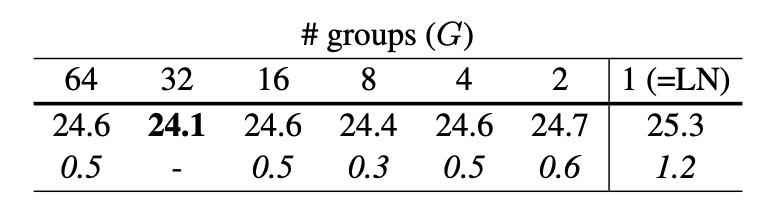

After having applied GroupNorm in the second model activations fluctuate after first epoch approximately in the range $(-5, +4]$

In [ ]:
class UNetPlusGroupNorm(nn.Module):
    def __init__(self, time_dim: int = 128) -> None:
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU()
        )
        
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.gn1 = nn.GroupNorm(8, 32)
        self.te1 = nn.Linear(time_dim, 32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1, stride=2)
        self.gn2 = nn.GroupNorm(8, 64)
        self.te2 = nn.Linear(time_dim, 64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1, stride=2)
        self.gn3 = nn.GroupNorm(8, 128)
        self.te3 = nn.Linear(time_dim, 128)
        
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)
        self.gn4 = nn.GroupNorm(8, 64)
        self.te4 = nn.Linear(time_dim, 64)
        self.up2 = nn.ConvTranspose2d(128, 32, kernel_size=4, stride=2, padding=1)
        self.gn5 = nn.GroupNorm(8, 32)
        self.te5 = nn.Linear(time_dim, 32)
        
        self.out = nn.Conv2d(64, 1, kernel_size=3, padding=1)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_mlp(t)
        
        def inject_time(h: torch.Tensor, time_proj: nn.Linear) -> torch.Tensor:
            return h + time_proj(t_emb)[..., None, None]
        #Convoluzione -> GroupNorm -> Add Time -> ReLU
        x1 = F.relu(inject_time(self.gn1(self.conv1(x)), self.te1))
        #x1 = F.relu(self.gn1(inject_time(self.conv1(x), self.te1)))
        x2 = F.relu(inject_time(self.gn2(self.conv2(x1)), self.te2))
        x3 = F.relu(inject_time(self.gn3(self.conv3(x2)), self.te3))
        x4 = F.relu(inject_time(self.gn4(self.up1(x3)), self.te4))
        x4 = torch.cat([x4, x2], dim=1)
        x5 = F.relu(inject_time(self.gn5(self.up2(x4)), self.te5))
        x5 = torch.cat([x5, x1], dim=1)
        
        return self.out(x5)

In [ ]:
#training[11:24<00:00, 34.18s/it]
#denoising[00:04<00:00, 271.06it/s]
activation_h2 = {
    "steps": [],
    "means": [],
    "stds": [],
    "mins": [],
    "maxs": []
}

def peak_into_activations2(module, input, output):
    out_detached = output.detach().cpu()
    activation_h2["means"].append(out_detached.mean().item())
    activation_h2["stds"].append(out_detached.std().item())
    activation_h2["mins"].append(out_detached.min().item())
    activation_h2["maxs"].append(out_detached.max().item())
    
lr = 2e-4 #1e-3
model = UNetPlusGroupNorm(time_dim=128).to(device)
model.conv3.register_forward_hook(peak_into_activations2)
opt = optim.Adam(model.parameters(), lr=lr)
epochs = 50 if not test else 1#20
losses_h = fit(epochs=epochs, train_dl=train_dl, model=model, opt=opt, device=device)
model.eval()
n_samples = 16
x_trajectory = torch.randn(n_samples, 1, 28, 28, device=device)

with torch.no_grad():
    for t_idx in tqdm(reversed(range(T)), total=T, desc="Denoising Steps"):
        t_batch = torch.full((n_samples,), t_idx, device=device, dtype=torch.float)
        pred_noise = model(x_trajectory, t_batch)
        beta_t = betas[t_idx]
        alpha_t = alphas[t_idx]
        alpha_cumprod_t = alphas_cumprod[t_idx]
        mu_coefficient = 1. / torch.sqrt(alpha_t)
        noise_coef = beta_t / torch.sqrt(1. - alpha_cumprod_t)
        mu_theta = mu_coefficient * (x_trajectory - noise_coef * pred_noise)
        
        if t_idx > 0:
            z = torch.randn_like(x_trajectory)
            sigma_t = sigmas[t_idx]
            x_trajectory = mu_theta + sigma_t * z
        else:
            x_trajectory = mu_theta

new_imgs = ((x_trajectory.cpu() + 1) / 2.0).clamp(0, 1)
grid_img = torchvision.utils.make_grid(new_imgs, nrow=4)
grid_np = grid_img.numpy().transpose((1, 2, 0))
fig = px.imshow(
    grid_np, 
    title=f"DPM Generated Digits (Epochs: {epochs})"
)
fig.show()
plot_activation_trends(activation_h2)

## FIX: EMA

In [ ]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow_copy = {k: v.detach().clone() for k, v in model.state_dict().items()}

    @torch.no_grad()
    def update(self, model):
        for k, v in model.state_dict().items():
            if v.dtype.is_floating_point:
                self.shadow_copy[k] = self.decay * self.shadow_copy[k] + (1 - self.decay) * v
            else:
                self.shadow_copy[k] = v.detach().clone()
    def copy_to(self, model):
        model.load_state_dict(self.shadow_copy, strict=False)
    def state_dict(self):
        return self.shadow_copy

    def load_state_dict(self, sd):
        self.shadow_copy = {k: v.clone() for k, v in sd.items()}
def fitEMA(
    epochs: int,
    train_dl,
    model: nn.Module,
    opt: optim.Optimizer,
    device: str = "mps" # or cuda
) -> tuple:
    
    ema = EMA(model, decay=0.999)
    losses_history = []
    
    for epoch in trange(epochs, desc="train epoch"):
        model.train()
        train_loss_averager = make_averager()
        tqdm_iterator = tqdm(
            enumerate(train_dl),
            total=len(train_dl),
            desc="train batch [avg loss: None]",
            leave=False,
        )
        for _, (xb, _) in tqdm_iterator:
            x_clean = xb.to(device)
            batch_size = x_clean.shape[0]
            t = torch.randint(0, T, (batch_size,), device=device).long()
            noise = torch.randn_like(x_clean)
            x_noisy = q_sample(x_clean, t, noise)
            
            opt.zero_grad()
            pred_noise = model(x_noisy, t.float())
            loss = F.mse_loss(pred_noise, noise)
            loss.backward()
            opt.step()
            
            ema.update(model)
            
            train_loss_averager(loss.item())
            tqdm_iterator.set_description(
                f"train batch [avg loss: {train_loss_averager(None):.5f}]"
            )
            tqdm_iterator.refresh()
            
        epoch_loss = train_loss_averager(None)
        losses_history.append(epoch_loss)
        
        print(
            f"Epoch: {epoch + 1}\n"
            f"Train set: Average loss: {epoch_loss:.5f}\n"
        )
        
    return losses_history, ema

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, time_dim: int, 
                 stride: int = 1, transpose: bool = False):
        super().__init__()
        if transpose:
            self.conv = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=stride, padding=1)
        else:
            self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1)
        self.gn = nn.GroupNorm(8, out_ch)
        self.te = nn.Linear(time_dim, out_ch)

    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        h = self.gn(self.conv(x))
        h = h + self.te(t_emb)[..., None, None]
        return F.relu(h)

class UNetPlusEmaAndNorm(nn.Module):
    def __init__(self, time_dim: int = 128) -> None:
        super().__init__()
        
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU()
        )
        
        self.block1 = UBlock(1, 32, time_dim, stride=1)
        self.block2 = UBlock(32, 64, time_dim, stride=2)
        self.block3 = UBlock(64, 128, time_dim, stride=2)
        
        self.up1 = UBlock(128, 64, time_dim, stride=2, transpose=True)
        self.up2 = UBlock(128, 32, time_dim, stride=2, transpose=True)
        
        self.out = nn.Conv2d(64, 1, kernel_size=3, padding=1)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_mlp(t)
        x1 = self.block1(x, t_emb)
        x2 = self.block2(x1, t_emb)
        x3 = self.block3(x2, t_emb)
        
        x4 = self.up1(x3, t_emb)
        x4 = torch.cat([x4, x2], dim=1)
        x5 = self.up2(x4, t_emb)
        x5 = torch.cat([x5, x1], dim=1)
        return self.out(x5)

activation_h2 = {
    "steps": [],
    "means": [],
    "stds": [],
    "mins": [],
    "maxs": []
}

def peak_into_activations2(module, input, output):
    out_detached = output.detach().cpu()
    activation_h2["means"].append(out_detached.mean().item())
    activation_h2["stds"].append(out_detached.std().item())
    activation_h2["mins"].append(out_detached.min().item())
    activation_h2["maxs"].append(out_detached.max().item())
    
lr = 2e-4
model = UNetPlusEmaAndNorm(time_dim=128).to(device)
model.block3.conv.register_forward_hook(peak_into_activations2)
opt = optim.Adam(model.parameters(), lr=lr)
epochs = 50 if not test else 1
losses_h, ema = fitEMA(epochs=epochs, train_dl=train_dl, model=model, opt=opt, device=device)

ema_model = UNetPlusEmaAndNorm(time_dim=128).to(device)
ema.copy_to(ema_model)
ema_model.eval()

n_samples = 16
x_trajectory = torch.randn(n_samples, 1, 28, 28, device=device)

with torch.no_grad():
    for t_idx in tqdm(reversed(range(T)), total=T, desc="Denoising Steps"):
        t_batch = torch.full((n_samples,), t_idx, device=device, dtype=torch.float)
        pred_noise = ema_model(x_trajectory, t_batch) 
        beta_t = betas[t_idx]
        alpha_t = alphas[t_idx]
        alpha_cumprod_t = alphas_cumprod[t_idx]
        mu_coefficient = 1. / torch.sqrt(alpha_t)
        noise_coef = beta_t / torch.sqrt(1. - alpha_cumprod_t)
        mu_theta = mu_coefficient * (x_trajectory - noise_coef * pred_noise)
        
        if t_idx > 0:
            z = torch.randn_like(x_trajectory)
            sigma_t = sigmas[t_idx]
            x_trajectory = mu_theta + sigma_t * z
        else:
            x_trajectory = mu_theta

new_imgs = ((x_trajectory.cpu() + 1) / 2.0).clamp(0, 1)
grid_img = torchvision.utils.make_grid(new_imgs, nrow=4)
grid_np = grid_img.numpy().transpose((1, 2, 0))
fig = px.imshow(
    grid_np, 
    title=f"DPM Generated Digits (Epochs: {epochs} w/ EMA)"
)
fig.show()
plot_activation_trends(activation_h2)

## FIX: increase receptive field

In [ ]:
class UBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.gn1 = nn.GroupNorm(8, out_ch)
        self.te1 = nn.Linear(time_dim, out_ch)
        
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.gn2 = nn.GroupNorm(8, out_ch)
        self.te2 = nn.Linear(time_dim, out_ch)
        
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = self.gn1(h)
        h = h + self.te1(t_emb)[..., None, None]
        h = F.relu(h)
        h = self.conv2(h)
        h = self.gn2(h)
        h = h + self.te2(t_emb)[..., None, None]
        return F.relu(h + self.skip(x))

class UNetDeepV2(nn.Module):
    def __init__(self, time_dim: int = 128) -> None:
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU()
        )
        self.down1_a = UBlock(1, 64, time_dim)
        self.down1_b = UBlock(64, 64, time_dim)
        self.pool1 = nn.Conv2d(64, 64, 3, stride=2, padding=1)
        self.down2_a = UBlock(64, 128, time_dim)
        self.down2_b = UBlock(128, 128, time_dim)
        self.pool2 = nn.Conv2d(128, 128, 3, stride=2, padding=1)
        self.mid1 = UBlock(128, 128, time_dim)
        self.mid2 = UBlock(128, 128, time_dim)
        self.mid3 = UBlock(128, 128, time_dim)
        self.up1 = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1) 
        self.up_block1_a = UBlock(192, 128, time_dim)
        self.up_block1_b = UBlock(128, 64, time_dim)
        self.up2 = nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1)
        self.up_block2_a = UBlock(96, 64, time_dim)
        self.up_block2_b = UBlock(64, 32, time_dim)
        self.out = nn.Conv2d(32, 1, 3, padding=1)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_mlp(t)
        d1 = self.down1_a(x, t_emb)
        d1 = self.down1_b(d1, t_emb)
        p1 = self.pool1(d1)
        d2 = self.down2_a(p1, t_emb)
        d2 = self.down2_b(d2, t_emb)
        p2 = self.pool2(d2)
        m = self.mid1(p2, t_emb)
        m = self.mid2(m, t_emb)
        m = self.mid3(m, t_emb)
        u1 = self.up1(m)
        u1 = torch.cat([u1, d2], dim=1)
        u1 = self.up_block1_a(u1, t_emb)
        u1 = self.up_block1_b(u1, t_emb)
        u2 = self.up2(u1)
        u2 = torch.cat([u2, d1], dim=1)
        u2 = self.up_block2_a(u2, t_emb)
        u2 = self.up_block2_b(u2, t_emb)
        return self.out(u2)

In [ ]:
lr = 2e-4
model = UNetDeepV2(time_dim=128).to(device)
opt = optim.Adam(model.parameters(), lr=lr)
epochs = 50 if not test else 1
losses_h, ema = fitEMA(epochs=epochs, train_dl=train_dl, model=model, opt=opt, device=device)
ema_model = UNetDeepV2(time_dim=128).to(device)
ema.copy_to(ema_model)
ema_model.eval()
n_samples = 16
x_trajectory = torch.randn(n_samples, 1, 28, 28, device=device)
with torch.no_grad():
    for t_idx in tqdm(reversed(range(T)), total=T, desc="Denoising Steps"):
        t_batch = torch.full((n_samples,), t_idx, device=device, dtype=torch.float)
        pred_noise = ema_model(x_trajectory, t_batch) 
        beta_t = betas[t_idx]
        alpha_t = alphas[t_idx]
        alpha_cumprod_t = alphas_cumprod[t_idx]
        mu_coefficient = 1. / torch.sqrt(alpha_t)
        noise_coef = beta_t / torch.sqrt(1. - alpha_cumprod_t)
        mu_theta = mu_coefficient * (x_trajectory - noise_coef * pred_noise)
        if t_idx > 0:
            z = torch.randn_like(x_trajectory)
            sigma_t = sigmas[t_idx]
            x_trajectory = mu_theta + sigma_t * z
        else:
            x_trajectory = mu_theta

In [ ]:
new_imgs = ((x_trajectory.cpu() + 1) / 2.0).clamp(0, 1)
grid_img = torchvision.utils.make_grid(new_imgs, nrow=4)
grid_np = grid_img.numpy().transpose((1, 2, 0))
fig = px.imshow(
    grid_np, 
    title=f"DPM generated digits ({epochs} epochs)"
)
fig.show()
#plot_activation_trends(activation_h2)

## Latent Diffusion

Before going into the details of latent diffusion, I add here some utilities to work on custom dataset. In particular I collected 2 datasets:
- **botanical garden dataset**: photos of plants from *Orto Botanico di Roma* collected during Hanami Festival in April 2026 from my Iphone 13 Pro as 4K 30 fps videos then converted into photos and cleaned from semantic duplicates through CLIP embeddings.
- **museum dataset**: videos from Galleria Nazionale di Arte Moderna e Contemporanea collected the 5th July 2026 from my Iphone 13 Pro as HD 30 fps videos then converted into photos and cleaned from semantic duplicates through CLIP embeddings.


In [ ]:
"""
video_folder = r'C:/Users/Yeyian Gaming/Downloads/musei_vids'
output_folder = r'C:/Users/Yeyian Gaming/Desktop/Foto_Tmp'
os.makedirs(output_folder, exist_ok=True)
video_files = [f for f in os.listdir(video_folder) if f.lower().endswith('.mov')]
print(f"found {len(video_files)} .mov videos to process.")
for video_name in video_files:
    video_path = os.path.join(video_folder, video_name)
    base_name = os.path.splitext(video_name)[0]
    print(f"processing: {video_name}")
    capture = cv2.VideoCapture(video_path)
    frame_count = 0
    while True:
        success, frame = capture.read()
        if not success:
            break
        resized_frame = cv2.resize(frame, (128, 256))
        frame_name = f"{base_name}_frame_{frame_count:04d}.png"
        cv2.imwrite(os.path.join(output_folder, frame_name), resized_frame)
        frame_count += 1
    capture.release()
    print(f"extracted {frame_count} frames.")
print(f"process completed, all frames saved in: {output_folder}")
"""

In [ ]:
"""
video_folder = r'C:/Users/Yeyian Gaming/Downloads/musei_vids'
output_folder = r'C:/Users/Yeyian Gaming/Desktop/museum_orig'
os.makedirs(output_folder, exist_ok=True)
video_files = [f for f in os.listdir(video_folder) if f.lower().endswith('.mov')]
print(f"Found {len(video_files)} .mov videos to process.")
for video_name in video_files:
    video_path = os.path.join(video_folder, video_name)
    base_name = os.path.splitext(video_name)[0]
    print(f"Processing: {video_name}")
    capture = cv2.VideoCapture(video_path)
    frame_count = 0
    while True:
        success, frame = capture.read()
        if not success:
            break
        frame_name = f"{base_name}_frame_{frame_count:04d}.png"
        cv2.imwrite(os.path.join(output_folder, frame_name), frame)
        frame_count += 1
    capture.release()
    print(f"extracted {frame_count} frames")
"""

In [ ]:
DATA_DIR = "data/museum"# "data/botanical_garden_512x896" # "data/museum_512x896"
DUPLICATES_DIR = "data/museum_duplicates" #"data/museum_duplicates"# "data/botanical_garden_duplicates" 

In [ ]:
"""
#74k->14250 
#38763 -> 4690
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs(DUPLICATES_DIR, exist_ok=True)
print("CLIP model loading")
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()
paths = sorted(list(Path(DATA_DIR).rglob("*.jpg")) + list(Path(DATA_DIR).rglob("*.jpeg")) + list(Path(DATA_DIR).rglob("*.png")))
print(f"found {len(paths)} imgs, starting semantic deduplication")
kept_count = 0
duplicate_count = 0
last_emb = None
for path in tqdm(paths, desc="Elaborazione frame"):
    try:
        img = preprocess(Image.open(path)).unsqueeze(0).to(device)
        with torch.no_grad():
            e = model.encode_image(img)
            e = e / e.norm(dim=-1, keepdim=True)
        if last_emb is None or (e @ last_emb.T).item() < 0.95:
            last_emb = e
            kept_count += 1
        else:
            new_path = os.path.join(DUPLICATES_DIR, path.name)
            os.rename(path, new_path)
            duplicate_count += 1
    except Exception as e_msg:
        print(f"error on file {path}: {e_msg}")
print("done")
print(f"{kept_count} unique images left in data directory")
print(f"{duplicate_count} duplicated images moved to duplicate directory")
"""

Verify you have the museum directory

In [ ]:
assert os.path.exists(DATA_DIR), f"The dataset directory '{DATA_DIR}' does not exist."
assert len(os.listdir(DATA_DIR)) > 0, f"The dataset directory '{DATA_DIR}' is empty."

I set all the constants and hyperparameters (learning rates, batch sizes, model dimensions).

I select through if/else logic the dataset I'm interested in.

`set_seed(0)` for reproducibility.

In [ ]:
DATASET_CHOICE = "museum"#"museum"  # "celeba" # "botanical"
IMAGE_SIZE = 32
IMAGE_WIDTH = 128
IMAGE_HEIGHT = 256
CHANNELS = 3
BASE_CH = 128
TIME_DIM = 512
NUM_WORKERS = 0
LR = 2e-4
EPOCHS = 200 if not test else 1
SAVE_EVERY = 5
VAE_BATCH_SIZE = 4
LDM_BATCH_SIZE = 16
VAE_BASE = 64
LATENT_CHANNELS = 4
VAE_EPOCHS = 100 if not test else 1
VAE_LR = 1e-4
KL_WEIGHT = 1e-4
PERC_WEIGHT = 1.0

if DATASET_CHOICE == "botanical":
    DATA_DIR = "data/botanical_garden"
    PREPROCESSED_DIR = "data/botanical_garden_32x32"
    HIGHER_RES_PREPROCESSED_DIR = "data/botanical_garden_512x896"
    OUT_DIR = "./checkpoints_botanical"
    CKPT_PREFIX = "botanical_attn_v4"
elif DATASET_CHOICE == "museum":
    DATA_DIR = "data/museum"
    PREPROCESSED_DIR = "data/museum_32x32"
    HIGHER_RES_PREPROCESSED_DIR = "data/museum"
    OUT_DIR = "./checkpoints_museum"
    CKPT_PREFIX = "museum_attn_v1"
elif DATASET_CHOICE == "celeba":
    DATA_DIR = "data/celeba_hq_256"
    PREPROCESSED_DIR = "data/celeba_hq_32x32"
    OUT_DIR = "./checkpoints_celeba"
    CKPT_PREFIX = "celeba_attn"
else:
    raise ValueError(f"Dataset non riconosciuto: {DATASET_CHOICE}")

VAE_CKPT_PREFIX = f"{CKPT_PREFIX}_vae"
os.makedirs(OUT_DIR, exist_ok=True)
set_seed(0)

Verify you have the data

In [ ]:
assert os.path.exists(HIGHER_RES_PREPROCESSED_DIR), f"Preprocessed root folder '{HIGHER_RES_PREPROCESSED_DIR}' specified by DATASET_CHOICE does not exist."
_check_path = Path(HIGHER_RES_PREPROCESSED_DIR)
_found_imgs = list(_check_path.rglob("*.jpg")) + list(_check_path.rglob("*.jpeg")) + list(_check_path.rglob("*.png"))
assert len(_found_imgs) > 0, f"No target images (.jpg, .jpeg, .png) found inside configuration folder '{HIGHER_RES_PREPROCESSED_DIR}'."

I load, resize and normalize images and check sizes are correct before training.

In [ ]:
class LatentDiffImgDataset(Dataset):
    def __init__(self, root):
        root = Path(root)
        self.paths = sorted(
            list(root.rglob("*.jpg")) + list(root.rglob("*.jpeg")) + list(root.rglob("*.png"))
        )
        assert len(self.paths) > 0, f"No img in {root}"
        self.transform = transforms.Compose([
            transforms.Resize((IMAGE_HEIGHT, IMAGE_WIDTH)),
            transforms.ToTensor(),
            transforms.Normalize([0.5] * 3, [0.5] * 3),
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i])
        img = ImageOps.exif_transpose(img)
        img = img.convert("RGB")
        return self.transform(img)

dataset = LatentDiffImgDataset(HIGHER_RES_PREPROCESSED_DIR)
_sample = dataset[0]
assert _sample.shape == (CHANNELS, IMAGE_HEIGHT, IMAGE_WIDTH), (
    f"expected images of shape {(CHANNELS, IMAGE_HEIGHT, IMAGE_WIDTH)}, "
    f"but got {tuple(_sample.shape)}"
)
print(f"loaded {len(dataset)} imgs of size {IMAGE_WIDTH}x{IMAGE_HEIGHT}")

I initialized the data loaders using `pin_memory=True` to enable faster transfers to the GPU.

I save checkpoints and resume training from the most recent training file.

In [ ]:
vae_loader = DataLoader(
    dataset, batch_size=VAE_BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
    pin_memory=True, drop_last=True, persistent_workers=NUM_WORKERS > 0,
)
ldm_loader = DataLoader(
    dataset, batch_size=LDM_BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
    pin_memory=True, drop_last=True, persistent_workers=NUM_WORKERS > 0,
)

def save_checkpoint(state: dict, prefix: str, epoch: int) -> str:
    path = os.path.join(OUT_DIR, f"{prefix}_epoch{epoch:04d}.pt")
    torch.save(state, path)
    return path

def find_latest_checkpoint(prefix: str):
    ckpts = glob.glob(os.path.join(OUT_DIR, f"{prefix}_epoch*.pt"))
    if not ckpts:
        return None
    def epoch_of(p):
        m = re.search(r"epoch(\d+)", p)
        return int(m.group(1)) if m else -1
    return max(ckpts, key=epoch_of)

I defined some basic building blocks:
- Group Normalization and a safeguard to match the channel dimensions
- ResBlocks with skip connections to preserve information across deep layers and stabilize gradient flow
- Downsample module for feature compression
- Upsample layers which use nearest neighbor interpolation to increase feature map resolution by simply duplicating adjacent pixel values. The following convolutional layers will refine the details.

In [ ]:
def gn(ch: int, max_groups: int = 8) -> nn.GroupNorm:
    g = max_groups
    while g > 1 and ch % g != 0:
        g -= 1
    return nn.GroupNorm(g, ch)

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.n1 = gn(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.n2 = gn(out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        h = F.silu(self.n1(self.conv1(x)))
        h = self.n2(self.conv2(h))
        return F.silu(h + self.skip(x))

class Downsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.op = nn.Conv2d(ch, ch, 4, stride=2, padding=1)

    def forward(self, x):
        return self.op(x)

class Upsample(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="nearest")
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1)

    def forward(self, x):
        return self.conv(self.up(x))

I define a VAE which encodes images into a latent space having 4 channels and then reconstruct them.

It has 5.8 million parameters and a symmetrical structure: an encoder with 3 downsampling stages to compress features and a decoder with 3 upsampling stages for reconstruction.

In [ ]:
class VAE(nn.Module):
    def __init__(self, in_channels=3, latent_dim=4, base=64):
        super().__init__()
        c1, c2, c3 = base, base * 2, base * 4
        self.conv_in = nn.Conv2d(in_channels, c1, 3, padding=1)
        self.enc1 = ResBlock(c1, c1)
        self.down1 = Downsample(c1)
        self.enc2 = ResBlock(c1, c2)
        self.down2 = Downsample(c2)
        self.enc3 = ResBlock(c2, c3)
        self.down3 = Downsample(c3)
        self.enc4 = ResBlock(c3, c3)
        self.mu = nn.Conv2d(c3, latent_dim, 1)
        self.logvar = nn.Conv2d(c3, latent_dim, 1)
        self.dec_in = nn.Conv2d(latent_dim, c3, 1)
        self.dec1 = ResBlock(c3, c3)
        self.up1 = Upsample(c3, c2)
        self.dec2 = ResBlock(c2, c2)
        self.up2 = Upsample(c2, c1)
        self.dec3 = ResBlock(c1, c1)
        self.up3 = Upsample(c1, c1)
        self.dec4 = ResBlock(c1, c1)
        self.conv_out = nn.Conv2d(c1, in_channels, 3, padding=1)

    def encode(self, x):
        h = self.conv_in(x)
        h = self.enc1(h)
        h = self.down1(h)
        h = self.enc2(h)
        h = self.down2(h)
        h = self.enc3(h)
        h = self.down3(h)
        h = self.enc4(h)
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z):
        h = self.dec_in(z)
        h = self.dec1(h)
        h = self.up1(h)
        h = self.dec2(h)
        h = self.up2(h)
        h = self.dec3(h)
        h = self.up3(h)
        h = self.dec4(h)
        return torch.tanh(self.conv_out(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [ ]:
vae = VAE(in_channels=CHANNELS, latent_dim=LATENT_CHANNELS, base=VAE_BASE).to(device)
input_size = (1, 3, 256, 128)
summary(vae, input_size)

I defined a loss function with 3 components: pixel-level accuracy, perceptual similarity and the regularity of the latent space.

$$\mathcal{L}_{total} = \mathcal{L}_{L1} + \omega_{p} \mathcal{L}_{LPIPS} + \omega_{kl} \mathcal{L}_{KL}$$

- **Reconstruction Loss ($\mathcal{L}_{L1}$):** the mean absolute error between the original input $x$ and the reconstruction $\hat{x}$ ($||x - \hat{x}||_1$). $L1$ in place of $MSE$ preserves sharper edges by not penalizing small pixel variations too hard.
- **Perceptual Loss ($\mathcal{L}_{LPIPS}$):** the distance between images using a pre-trained **VGG network**, a deep convolutional network trained on ImageNet and used as a *feature extractor*. Comparing feature maps rather than raw pixels, the model focuses on structural and semantic similarity.
- **KL Divergence ($\mathcal{L}_{KL}$):** a regularizer ($-\frac{1}{2} \sum (1 + \log(\sigma^2) - \mu^2 - \sigma^2)$) to ensure the latent distribution follows a standard normal distribution.

To have an efficient training and optimized memory usage I set the VGG network in evaluation mode and used a `GradScaler` for mixed-precision training.

I also added the possibility to change the weights $\omega_{p}$ and $\omega_{kl}$ for the perceptual and KL loss components.

In [ ]:
lpips_fn = lpips.LPIPS(net="vgg").to(device)
lpips_fn.eval()
for p in lpips_fn.parameters():
    p.requires_grad = False

def vae_loss_fn(recon_x, x, mu, logvar, perc_weight=1.0, beta=1e-4):
    recon_loss = F.l1_loss(recon_x, x)
    perc_loss = lpips_fn(recon_x, x).mean()
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    total = recon_loss + perc_weight * perc_loss + beta * kl
    return total, recon_loss, perc_loss, kl

vae.to(device)
vae_opt = optim.Adam(vae.parameters(), lr=VAE_LR)
vae_scaler = torch.amp.GradScaler(enabled=(device.type == "cuda"))

The training part resumes from the latest checkpoint. And the same story again... In each epoch I compute losses and update the model weights.

Periodically I save a checkpoint.

In [ ]:
start_epoch = 0
_ckpt_path = find_latest_checkpoint(VAE_CKPT_PREFIX)
if _ckpt_path is not None:
    print(f"Resuming VAE from {_ckpt_path}")
    ckpt = torch.load(_ckpt_path, map_location=device)
    vae.load_state_dict(ckpt["model"])
    vae_opt.load_state_dict(ckpt["optim"])
    start_epoch = ckpt["epoch"] + 1
    vae_epoch = ckpt["epoch"]

print("training VAE")
for vae_epoch in range(start_epoch, VAE_EPOCHS):
    vae.train()
    t0 = time.time()
    agg = {"tot": 0.0, "rec": 0.0, "perc": 0.0, "kl": 0.0}
    for imgs in tqdm(vae_loader, desc=f"VAE {vae_epoch+1}/{VAE_EPOCHS}", leave=False):
        imgs = imgs.to(device, non_blocking=True)
        vae_opt.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            recon, mu, logvar = vae(imgs)
            loss, rec, perc, kl = vae_loss_fn(recon, imgs, mu, logvar, PERC_WEIGHT, KL_WEIGHT)
        vae_scaler.scale(loss).backward()
        vae_scaler.step(vae_opt)
        vae_scaler.update()
        agg["tot"] += loss.item()
        agg["rec"] += rec.item()
        agg["perc"] += perc.item()
        agg["kl"] += kl.item()
    n = len(vae_loader)
    dt = time.time() - t0
    print(f"epoch {vae_epoch+1}, tot {agg['tot']/n:.4f}, l1 {agg['rec']/n:.4f}, lpips {agg['perc']/n:.4f}, kl {agg['kl']/n:.4f}, {dt/60:.1f} min")
    if (vae_epoch + 1) % SAVE_EVERY == 0 or (vae_epoch + 1) == VAE_EPOCHS:
        save_checkpoint({"model": vae.state_dict(), "optim": vae_opt.state_dict(), "epoch": vae_epoch}, VAE_CKPT_PREFIX, vae_epoch + 1)

I created a diagnostic function on my VAE learning: it takes a few real images, runs them through the model, and stacks the originals above the reconstructions to see if the output is too blurry.

In [ ]:
@torch.no_grad()
def check_vae(vae, dataloader, device, num_samples=4, save_path=None):
    vae.eval()
    imgs = next(iter(dataloader))[:num_samples].to(device)
    recon, _, _ = vae(imgs)
    imgs = ((imgs.cpu() + 1) / 2).clamp(0, 1)
    recon = ((recon.cpu() + 1) / 2).clamp(0, 1)
    grid_top = torchvision.utils.make_grid(imgs, nrow=num_samples)
    grid_bot = torchvision.utils.make_grid(recon, nrow=num_samples)
    grid = torch.cat([grid_top, grid_bot], dim=1)
    fig, ax = plt.subplots(figsize=(3 * num_samples, 8))
    ax.imshow(grid.permute(1, 2, 0).numpy())
    ax.axis("off")
    ax.set_title("VAE check: real (top) vs reconstructed (bottom)")
    if save_path:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()

check_vae(vae, vae_loader, device, num_samples=4, save_path=os.path.join(OUT_DIR, "vae_diagnostic.png"))

To normalize the latent space, I compute a **scale factor** ($s = 1/\sigma$), as suggested by Rombach et al. in *High-Resolution Image Synthesis with Latent Diffusion Models* (CVPR 2022). 

By running a few batches of images through the encoder, I compute the standard deviation of the resulting $z$ values and take its inverse.

Multiplying the latent outputs by this factor ensures they maintain unit variance ($\sigma \approx 1$), which prevents training instability and allows faster learning.

In [ ]:
#botan scale factor: 0.63175; museum: scale factor: 0.54933
vae.eval()
nr_batches = 10
latent_stds = []
LATENT_C = LATENT_H = LATENT_W = None
with torch.no_grad():
    for i, imgs in enumerate(vae_loader):
        if i >= nr_batches:
            break
        mu, logvar = vae.encode(imgs.to(device))
        z = vae.reparameterize(mu, logvar)
        latent_stds.append(z.flatten().cpu())
        if i == 0:
            _, LATENT_C, LATENT_H, LATENT_W = z.shape
scale_factor = 1.0 / torch.cat(latent_stds).std().item()
print(f"latent shape: {LATENT_C}x{LATENT_H}x{LATENT_W}, scale factor: {scale_factor:.5f}")

In [ ]:
def cosine_alphas_cumprod(T, s=0.008):
    steps = torch.arange(T + 1, dtype=torch.float64)
    f = torch.cos(((steps / T + s) / (1 + s)) * math.pi / 2) ** 2
    return f / f[0]

acp = cosine_alphas_cumprod(T)
alphas_cumprod = acp[1:].float().to(device)
alphas_cumprod_prev = acp[:-1].float().to(device)
betas = (1 - acp[1:] / acp[:-1]).clamp(max=0.999).float().to(device)
alphas = 1.0 - betas
sigmas = torch.sqrt(betas * (1 - alphas_cumprod_prev) / (1 - alphas_cumprod)).to(device)
sqrt_acp = torch.sqrt(alphas_cumprod)
sqrt_1macp = torch.sqrt(1 - alphas_cumprod)

def get_v(x0, noise, t):
    a = sqrt_acp[t][:, None, None, None]
    b = sqrt_1macp[t][:, None, None, None]
    return a * noise - b * x0

I defined a `SelfAttention2d` block which normalizes the input and passes it through a $1 \times 1$ convolution to generate Queries, Keys and Values from the same feature map $X$. Every pixel in the image communicate with every other pixel rather than just with its immediate neighbors. The model gets a sense of global geometry and structure.

The main difference between this and the `CrossAttentionBlock` is who talks to whom: self-attention keeps everything inside the image using $Q=W_q X, K=W_k X, V=W_v X$, while cross-attention uses the image as a Query ($Q=W_q X$) to ask an external context $Y$ for Keys and Values ($K=W_k Y, V=W_v Y$), mapping visual features to textual concepts.

Both blocks run on the exact same math
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{Q K^T}{\sqrt{d_k}}\right)V$$

In [ ]:
class UBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.gn1 = gn(out_ch)
        self.te1 = nn.Linear(time_dim, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.gn2 = gn(out_ch)
        self.te2 = nn.Linear(time_dim, out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.gn1(self.conv1(x)) + self.te1(t_emb)[..., None, None]
        h = F.silu(h)
        h = self.gn2(self.conv2(h)) + self.te2(t_emb)[..., None, None]
        return F.silu(h + self.skip(x))

class SelfAttention2d(nn.Module):
    def __init__(self, ch, num_heads=4):
        super().__init__()
        self.norm = gn(ch)
        self.qkv = nn.Conv2d(ch, ch * 3, 1)
        self.proj = nn.Conv2d(ch, ch, 1)
        self.num_heads = num_heads
    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)
        qkv = self.qkv(h).reshape(B, 3, self.num_heads, C // self.num_heads, H * W)
        q, k, v = qkv[:, 0], qkv[:, 1], qkv[:, 2]
        attn = torch.softmax(q.transpose(-1, -2) @ k / math.sqrt(C // self.num_heads), dim=-1)
        out = (v @ attn.transpose(-1, -2)).reshape(B, C, H, W)
        return x + self.proj(out)

In [ ]:
class LatentUNet(nn.Module):
    def __init__(self, latent_channels=4, base=128, time_dim=512):
        super().__init__()
        c1, c2, c3 = base, base * 2, base * 4

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_dim),
            nn.Linear(time_dim, time_dim), nn.SiLU(),
            nn.Linear(time_dim, time_dim), nn.SiLU(),
        )
        self.in_conv = nn.Conv2d(latent_channels, c1, 3, padding=1)
        self.d1a = UBlock(c1, c1, time_dim)
        self.d1b = UBlock(c1, c1, time_dim)
        self.pool1 = nn.Conv2d(c1, c1, 4, stride=2, padding=1)
        self.d2a = UBlock(c1, c2, time_dim)
        self.d2_attn = SelfAttention2d(c2)
        self.d2b = UBlock(c2, c2, time_dim)
        self.pool2 = nn.Conv2d(c2, c2, 4, stride=2, padding=1)
        self.mid1 = UBlock(c2, c3, time_dim)
        self.mid_attn = SelfAttention2d(c3)
        self.mid2 = UBlock(c3, c3, time_dim)
        self.up2 = nn.ConvTranspose2d(c3, c3, 4, stride=2, padding=1)
        self.u2a = UBlock(c3 + c2, c2, time_dim)
        self.u2_attn = SelfAttention2d(c2)
        self.u2b = UBlock(c2, c2, time_dim)
        self.up1 = nn.ConvTranspose2d(c2, c2, 4, stride=2, padding=1)
        self.u1a = UBlock(c2 + c1, c1, time_dim)
        self.u1b = UBlock(c1, c1, time_dim)
        self.out = nn.Sequential(gn(c1), nn.SiLU(), nn.Conv2d(c1, latent_channels, 3, padding=1))

    def forward(self, x, t):
        temb = self.time_mlp(t)
        h = self.in_conv(x)
        h = self.d1a(h, temb)
        h = self.d1b(h, temb)
        skip1 = h
        h = self.pool1(h)
        h = self.d2a(h, temb)
        h = self.d2_attn(h)
        h = self.d2b(h, temb)
        skip2 = h
        h = self.pool2(h)
        h = self.mid1(h, temb)
        h = self.mid_attn(h)
        h = self.mid2(h, temb)
        h = torch.cat([self.up2(h), skip2], dim=1)
        h = self.u2a(h, temb)
        h = self.u2_attn(h)
        h = self.u2b(h, temb)
        h = torch.cat([self.up1(h), skip1], dim=1)
        h = self.u1a(h, temb)
        h = self.u1b(h, temb)
        return self.out(h)

In [ ]:
LDM_CKPT_PREFIX = f"{CKPT_PREFIX}_vae{vae_epoch}_ldm"
LATENT_SHAPE = (LATENT_C, LATENT_H, LATENT_W)
ldm_model = LatentUNet(latent_channels=LATENT_C, base=BASE_CH, time_dim=TIME_DIM).to(device)
ldm_opt = optim.Adam(ldm_model.parameters(), lr=LR)
ldm_scaler = torch.amp.GradScaler(enabled=(device.type == "cuda"))
ema_ldm = EMA(ldm_model, decay=0.9999)

I defined 2 functions to generate images through denoising.

`sample_ddpm` iterates through every step.

`sample_ddim` lets me skip steps to generate images faster.

In both cases the model predicts the noise at each step, I divide by my `scale_factor` to keep the values in the right range and then the VAE decodes the latent data into an image.

In [ ]:
@torch.no_grad()
def sample_ddpm(model, n_samples, latent_shape, vae, scale_factor, device):
    C, H, W = latent_shape
    model.eval()
    x = torch.randn(n_samples, C, H, W, device=device)
    for t_idx in tqdm(reversed(range(T)), total=T, desc="DDPM sampling"):
        t_batch = torch.full((n_samples,), t_idx, device=device, dtype=torch.float)
        pred_v = model(x, t_batch)
        eps = sqrt_1macp[t_idx] * x + sqrt_acp[t_idx] * pred_v
        beta_t, alpha_t, acp_t = betas[t_idx], alphas[t_idx], alphas_cumprod[t_idx]
        mu_coef = 1.0 / torch.sqrt(alpha_t)
        noise_coef = beta_t / torch.sqrt(1.0 - acp_t)
        mu_theta = mu_coef * (x - noise_coef * eps)
        if t_idx > 0:
            x = mu_theta + sigmas[t_idx] * torch.randn_like(x)
        else:
            x = mu_theta
    x = x / scale_factor
    return vae.decode(x)

@torch.no_grad()
def sample_ddim(model, n_samples, latent_shape, vae, scale_factor, device, steps=50, eta=0.0):
    C, H, W = latent_shape
    model.eval()
    step_indices = torch.linspace(T - 1, 0, steps, device=device).long()
    x = torch.randn(n_samples, C, H, W, device=device)
    for i, t_idx in enumerate(tqdm(step_indices, desc="DDIM sampling")):
        t_batch = torch.full((n_samples,), t_idx.item(), device=device, dtype=torch.float)
        pred_v = model(x, t_batch)
        a_t = alphas_cumprod[t_idx]
        eps = sqrt_1macp[t_idx] * x + sqrt_acp[t_idx] * pred_v
        x0_pred = sqrt_acp[t_idx] * x - sqrt_1macp[t_idx] * pred_v
        if i + 1 < len(step_indices):
            a_prev = alphas_cumprod[step_indices[i + 1]]
        else:
            a_prev = torch.tensor(1.0, device=device)
        sigma = eta * torch.sqrt((1 - a_prev) / (1 - a_t) * (1 - a_t / a_prev))
        noise = torch.randn_like(x) if eta > 0 else 0.0
        x = torch.sqrt(a_prev) * x0_pred + torch.sqrt((1 - a_prev - sigma ** 2).clamp(min=0)) * eps + sigma * noise
    x = x / scale_factor
    return vae.decode(x)

I compute the **FID (Fréchet Inception Distance)**, a metric for evaluating generative quality. It compares the statistical distributions of real and generated images by mapping them into a 2048-dimensional feature space through an Inception-v3 network.

$$FID = ||\mu_r - \mu_g||^2 + Tr(\Sigma_r + \Sigma_g - 2(\Sigma_r \Sigma_g)^{1/2})$$

By comparing the means ($\mu$) and covariance matrices ($\Sigma$) of these feature distributions, the score penalizes both poor visual quality and mode collapse (where the variety of images is too low). A lower FID score indicates that my model's output is closer to the real data.

In [ ]:
@torch.no_grad()
def compute_fid(real_loader, model, vae, scale_factor, latent_shape, device,
                 n_real=200, n_fake=200, sample_steps=50, gen_batch=8):
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    seen = 0
    for imgs in real_loader:
        imgs = imgs.to(device)
        imgs_0_1 = ((imgs + 1) / 2).clamp(0, 1)
        fid.update(imgs_0_1, real=True)
        seen += imgs.shape[0]
        if seen >= n_real:
            break
    made = 0
    while made < n_fake:
        b = min(gen_batch, n_fake - made)
        fake = sample_ddim(model, b, latent_shape, vae, scale_factor, device, steps=sample_steps)
        fake_0_1 = ((fake + 1) / 2).clamp(0, 1)
        fid.update(fake_0_1, real=False)
        made += b
    return fid.compute().item()

I resume my diffusion model's training by reloading my model, optimizer, and EMA weights from the latest checkpoint.

In [ ]:
start_epoch = 0
latest_fid = None
loaded_vae_epochs = VAE_EPOCHS

_ckpt_path = find_latest_checkpoint(LDM_CKPT_PREFIX)
if _ckpt_path is not None:
    print(f"Resuming LDM from {_ckpt_path}")
    ckpt = torch.load(_ckpt_path, map_location=device)
    ldm_model.load_state_dict(ckpt["model"])
    ldm_opt.load_state_dict(ckpt["optim"])
    ema_ldm.load_state_dict(ckpt["ema"])
    start_epoch = ckpt["epoch"] + 1
    latest_fid = ckpt.get("fid_score", None)
    loaded_vae_epochs = ckpt.get("vae_epochs", VAE_EPOCHS)
    if latest_fid is not None:
        print(f"fid for checkpoint is {latest_fid:.3f}")
    print(f"VAE trained for {loaded_vae_epochs} epochs")

I defined a training loop for my Latent Diffusion Model.

I start by encoding images into latent space and scaling them to unit variance.

In each iteration I inject Gaussian noise into the latents and my U-Net has to predict a combination of the clean data and noise.

I use mixed-precision for efficiency and maintain an EMA of my model weights for better performance.

Periodically I compute the FID score to verify that the distribution of my generated images matches the real data.

I save a checkpoint containing my model, optimizer, and performance metrics so I can resume training later.

In [ ]:
print("latent diffusion model training (v-prediction)")
for epoch in range(start_epoch, EPOCHS):
    ldm_model.train()
    t0 = time.time()
    running = 0.0
    for imgs in tqdm(ldm_loader, desc=f"LDM {epoch+1}/{EPOCHS}", leave=False):
        imgs = imgs.to(device, non_blocking=True)
        with torch.no_grad():
            mu, _ = vae.encode(imgs)
            x_latent = mu * scale_factor  
        b = x_latent.shape[0]
        t = torch.randint(0, T, (b,), device=device).long()
        noise = torch.randn_like(x_latent)
        x_noisy = q_sample(x_latent, t, noise)
        ldm_opt.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            pred_v = ldm_model(x_noisy, t.float())
            v_target = get_v(x_latent, noise, t)
            loss = F.mse_loss(pred_v, v_target)
        ldm_scaler.scale(loss).backward()
        ldm_scaler.step(ldm_opt)
        ldm_scaler.update()
        ema_ldm.update(ldm_model)
        running += loss.item()

    n = len(ldm_loader)
    dt = time.time() - t0
    print(f"Epoch {epoch+1} | v-loss {running/n:.5f} | {dt/60:.1f} min")
    if (epoch + 1) % SAVE_EVERY == 0 or (epoch + 1) == EPOCHS:
        print(f"computing fid for epoch {epoch+1}")
        ema_ldm_eval = LatentUNet(latent_channels=LATENT_C, base=BASE_CH, time_dim=TIME_DIM).to(device)
        ema_ldm.copy_to(ema_ldm_eval)
        ema_ldm_eval.eval()
        current_fid = compute_fid(
            real_loader=ldm_loader,
            model=ema_ldm_eval,
            vae=vae,
            scale_factor=scale_factor,
            latent_shape=LATENT_SHAPE,
            device=device,
            n_real=200,        
            n_fake=200,        
            sample_steps=50,
            gen_batch=8
        )
        print(f"epoch {epoch+1} has fid {current_fid:.3f}")
        del ema_ldm_eval
        torch.cuda.empty_cache()
        save_checkpoint({
            "model": ldm_model.state_dict(),
            "optim": ldm_opt.state_dict(),
            "ema": ema_ldm.state_dict(),
            "epoch": epoch,
            "fid_score": current_fid,     
            "vae_epochs": vae_epoch       
        }, LDM_CKPT_PREFIX, epoch + 1)

Now I generate and visualize new images from my trained Latent Diffusion Model (LDM).

I load the **EMA** (Exponential Moving Average) version of my model, which is more stable and produces cleaner results.

I run `sample_ddim` to perform the diffusion process: denoise random latent vectors into images in 50 steps.

I rescale the output values to a standard 0-1 pixel range, save the results as a clean grid and plot them with a label to check if my model managed to create new images.

In [ ]:
ema_ldm_model = LatentUNet(latent_channels=LATENT_C, base=BASE_CH, time_dim=TIME_DIM).to(device)
ema_ldm.copy_to(ema_ldm_model)
ema_ldm_model.eval()
generated = sample_ddim(ema_ldm_model, n_samples=4, latent_shape=LATENT_SHAPE, vae=vae, scale_factor=scale_factor, device=device, steps=50)
imgs_0_1 = ((generated.cpu() + 1) / 2).clamp(0, 1)
grid = torchvision.utils.make_grid(imgs_0_1, nrow=2)
torchvision.utils.save_image(grid, os.path.join(OUT_DIR, "samples.png"))
fig, ax = plt.subplots(figsize=(8, 12))
ax.imshow(grid.permute(1, 2, 0).numpy())
ax.axis("off")
ax.set_title("Latent diffusion generated botanical images")
plt.savefig(os.path.join(OUT_DIR, "samples_labeled.png"), bbox_inches="tight")
plt.show()

I defined a function to visualize how my model turns noise gradually into a clean image during the sampling process.

I perform standard DDIM sampling at specific intervals, interrupt the denoising loop to run the VAE decoder on those latents. This gives me a progressive preview of the generation process.

This way I can see if the model is converging correctly.

In [ ]:
@torch.no_grad()
def sample_ddim_progressive(model, n_samples, latent_shape, vae, scale_factor, device, steps=50, eta=0.0, num_snapshots=5):
    C, H, W = latent_shape
    model.eval()
    step_indices = torch.linspace(T - 1, 0, steps, device=device).long()
    x = torch.randn(n_samples, C, H, W, device=device)
    snapshot_indices = torch.linspace(0, len(step_indices) - 1, num_snapshots).long().tolist()
    captured_grids = []
    captured_timesteps = []
    for i, t_idx in enumerate(tqdm(step_indices, desc="DDIM progressive sampling")):
        t_batch = torch.full((n_samples,), t_idx.item(), device=device, dtype=torch.float)
        if i in snapshot_indices:
            decoded_latents = x / scale_factor
            generated_pixels = vae.decode(decoded_latents)
            imgs_0_1 = ((generated_pixels.cpu() + 1) / 2).clamp(0, 1)
            grid = torchvision.utils.make_grid(imgs_0_1, nrow=2)
            captured_grids.append(grid.permute(1, 2, 0).numpy())
            captured_timesteps.append(t_idx.item())
        pred_v = model(x, t_batch)
        a_t = alphas_cumprod[t_idx]
        eps = sqrt_1macp[t_idx] * x + sqrt_acp[t_idx] * pred_v
        x0_pred = sqrt_acp[t_idx] * x - sqrt_1macp[t_idx] * pred_v
        if i + 1 < len(step_indices):
            a_prev = alphas_cumprod[step_indices[i + 1]]
        else:
            a_prev = torch.tensor(1.0, device=device)
        sigma = eta * torch.sqrt((1 - a_prev) / (1 - a_t) * (1 - a_t / a_prev))
        noise = torch.randn_like(x) if eta > 0 else 0.0
        x = torch.sqrt(a_prev) * x0_pred + torch.sqrt((1 - a_prev - sigma ** 2).clamp(min=0)) * eps + sigma * noise

    decoded_latents = x / scale_factor
    generated_pixels = vae.decode(decoded_latents)
    imgs_0_1 = ((generated_pixels.cpu() + 1) / 2).clamp(0, 1)
    grid = torchvision.utils.make_grid(imgs_0_1, nrow=2)
    if len(captured_grids) >= num_snapshots:
        captured_grids[-1] = grid.permute(1, 2, 0).numpy()
        captured_timesteps[-1] = 0
    else:
        captured_grids.append(grid.permute(1, 2, 0).numpy())
        captured_timesteps.append(0)
    return captured_grids, captured_timesteps

I set the EMA weights and generates a side by side visualization of the 1000 step DDIM denoising process, capturing 5 progressive snapshots.

At **`start t=999`** the snapshot looks like a mosaic puzzle of pixel groups rather than Gaussian noise. Even though the starting variable in the code is pure Gaussian noise, I'm viewing it *after* it passes through the **VAE decoder**.

VAE scales up a highly compressed latent space using convolutional filters, introducing spatial correlations and forcing the random noise into colour patches instead of independent pixels.

The U-Net in the subsequent steps ($t \to 0$) sharpens these puzzle pieces into a clean final image.

In [ ]:
LATENT_SHAPE = (LATENT_C, LATENT_H, LATENT_W)
NUM_SNAPSHOTS = 5
ema_ldm_model = LatentUNet(latent_channels=LATENT_C, base=BASE_CH, time_dim=TIME_DIM).to(device)
ema_ldm.copy_to(ema_ldm_model)
ema_ldm_model.eval()
print("Image generations by step")
grids, timesteps = sample_ddim_progressive(
    model=ema_ldm_model, 
    n_samples=4, 
    latent_shape=LATENT_SHAPE,
    vae=vae, 
    scale_factor=scale_factor, 
    device=device, 
    steps=1000, 
    num_snapshots=NUM_SNAPSHOTS
)
fig, axes = plt.subplots(1, NUM_SNAPSHOTS, figsize=(4 * NUM_SNAPSHOTS, 6))
for idx, (grid_np, t_val) in enumerate(zip(grids, timesteps)):
    axes[idx].imshow(grid_np)
    axes[idx].axis("off")
    if idx == 0:
        axes[idx].set_title(f"start t={t_val}", fontsize=12, fontweight='bold')
    elif idx == NUM_SNAPSHOTS - 1:
        axes[idx].set_title(f"end t={t_val}", fontsize=12, fontweight='bold')
    else:
        axes[idx].set_title(f"step {idx} t={t_val}", fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "progressive_denoising_sequence.png"), bbox_inches="tight")
plt.show()
final_grid_torch = torch.tensor(grids[-1]).permute(2, 0, 1)
torchvision.utils.save_image(final_grid_torch, os.path.join(OUT_DIR, "samples.png"))

## Multimodality

First of all I set the paramters of the latent space for a text-to-image latent diffusion model.

I initialized a pre-trained OpenAI CLIP text encoder and for efficiency I am freezing the encoder's weights. In this way I can translate text prompts into embeddings.

I extracted the dimensionality of the text embeddings (`hidden_size`), that is the number of numerical values used to represent each concept.

In [ ]:
IMG_SIZE = 64
LATENT_CHANNELS = 4
LATENT_SIZE = IMG_SIZE // 4
NULL_PROMPT = ""

tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")
text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
text_encoder.eval()
for p in text_encoder.parameters():
    p.requires_grad_(False)

CONTEXT_DIM = text_encoder.config.hidden_size
VAE_CKPT_PATH = "vae_checkpoint.pt"

I built a lookup of my flower labels and set the total number of classes.. The `download_flower_names` function downloads the mapping file if I don't have it and provides a default name for missing labels.

In [ ]:
def download_flower_names(filepath="./data/flower_to_name.json"):
    if not os.path.exists("./data"):
        os.makedirs("./data")
    url = "https://raw.githubusercontent.com/udacity/aipnd-project/master/cat_to_name.json"
    if not os.path.exists(filepath):
        print("downloading flower names")
        urllib.request.urlretrieve(url, filepath)
    with open(filepath, 'r') as f:
        data = json.load(f)
        return {int(k) - 1: v for k, v in data.items()}

FLOWER_NAMES = download_flower_names()
def get_flower_name(label_id):
    return FLOWER_NAMES.get(label_id, f"flower type {label_id}")

NUM_CLASSES = len(FLOWER_NAMES)

I convert text prompts into numerical **embeddings**. I add padding and text truncation because texts can have variable length and pass them to the CLIP encoder to generate semantic vectors. I also pre-calculated and cached these vectors for each flower class and for the null prompt (the empty string) used for Classifier-Free Guidance (details below). This way I can fastly retrieve the context. The `get_context_for_labels` function is a lookup of class IDs into their corresponding text representations.

In [ ]:
@torch.no_grad()
def get_text_embeddings(prompts):
    if isinstance(prompts, str):
        prompts = [prompts]
    inputs = tokenizer(prompts, padding="max_length", max_length=77, truncation=True, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    return text_encoder(**inputs).last_hidden_state

null_context = get_text_embeddings(NULL_PROMPT)
CLASS_PROMPTS = [f"a photo of a {get_flower_name(i)}" for i in range(NUM_CLASSES)]
class_context_cache = get_text_embeddings(CLASS_PROMPTS)
def get_context_for_labels(labels):
    return class_context_cache[labels.to(class_context_cache.device)]

I standardized, normalized, resized and merged the Oxford Flowers 102 dataset parts into a single `DataLoader`.

In [ ]:
flower_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
train_split = datasets.Flowers102(root='./data', split='train', download=True, transform=flower_transform)
val_split = datasets.Flowers102(root='./data', split='val', download=True, transform=flower_transform)
test_split = datasets.Flowers102(root='./data', split='test', download=True, transform=flower_transform)
full_dataset = ConcatDataset([train_split, val_split, test_split])
train_dl = DataLoader(full_dataset, batch_size=64, shuffle=True, drop_last=True, num_workers=2)
print(f"dataset contains {len(full_dataset)} imgs")

In [183]:
class VAEMultiModal(nn.Module):
    def __init__(self, in_channels=3, latent_dim=4, base=64):
        super().__init__()
        c1, c2 = base, base * 2
        self.enc = nn.Sequential(
            nn.Conv2d(in_channels, c1, 3, padding=1), ResBlock(c1, c1),
            nn.Conv2d(c1, c1, 4, stride=2, padding=1), ResBlock(c1, c2),
            nn.Conv2d(c2, c2, 4, stride=2, padding=1), ResBlock(c2, c2),
        )
        self.mu = nn.Conv2d(c2, latent_dim, 1)
        self.logvar = nn.Conv2d(c2, latent_dim, 1)
        self.dec_in = nn.Conv2d(latent_dim, c2, 1)
        self.dec = nn.Sequential(
            ResBlock(c2, c2), nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(c2, c1, 3, padding=1), ResBlock(c1, c1),
            nn.Upsample(scale_factor=2, mode='nearest'), nn.Conv2d(c1, c1, 3, padding=1),
            ResBlock(c1, c1), nn.Conv2d(c1, in_channels, 3, padding=1),
        )

    def encode(self, x):
        h = self.enc(x)
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z):
        return torch.tanh(self.dec(self.dec_in(z)))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [ ]:


vae_model = VAEMultiModal(in_channels=3, latent_dim=LATENT_CHANNELS, base=64).to(device)
vae_opt = optim.Adam(vae_model.parameters(), lr=1e-3)
vae_epochs = 100 if not test else 1

My `vae_loss_fn` is made of a reconstruction term and KL divergence but I also want to make sure the images look natural using the LPIPS perceptual loss from Zhang et al. (2018).

$$\mathcal{L}_{total} = \| \hat{x} - x \|_2^2 + \lambda_p \cdot \text{LPIPS}(\hat{x}, x) + \beta \cdot \text{KL}(q(z|x) || p(z))$$

I'm using `compute_scale_factor` as suggested in the Latent Diffusion paper by Rombach et al. (2022). To keep latent values from getting too wild, I compute a scale factor by taking the reciprocal of the average standard deviation across my latent vectors:

$$s = \frac{1}{\frac{1}{N} \sum_{i=1}^{N} \sigma_i}$$

In [ ]:
def vae_loss_fn(recon_x, x, mu, logvar, perc_weight=1.0, beta=1e-4):
    recon_loss = F.mse_loss(recon_x, x, reduction='mean')
    perc_loss = lpips_fn(recon_x, x).mean()
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    total = recon_loss + perc_weight * perc_loss + beta * kl_loss
    return total, recon_loss, perc_loss, kl_loss

@torch.no_grad()
def compute_scale_factor(vae_model, dataloader, num_batches=20):
    vae_model.eval()
    stds = []
    it = iter(dataloader)
    for _ in range(num_batches):
        try:
            xb, _ = next(it)
        except StopIteration:
            break
        xb = xb.to(device)
        mu, logvar = vae_model.encode(xb)
        z = vae_model.reparameterize(mu, logvar)
        stds.append(z.flatten().std().item())
    vae_model.train()
    return 1.0 / (sum(stds) / len(stds))

I'm saving checkpoints of my VAEMultiModal's progress, so I don't have to start from scratch if something goes wrong. By saving the model weights, optimizer state and training metrics, I can pick up exactly where I left off after a system crash, an OOM error, a Colab timeout, or even just my mom accidentally unplugging my computer while she's cleaning the room.

In [ ]:
def save_vae_checkpoint(path, epoch, model, optimizer, loss, scale_factor):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "loss": loss,
        "scale_factor": scale_factor,
    }, path)

def load_vae_checkpoint(path, model, optimizer):
    files = glob.glob(path)
    if not files:
        return None
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    print(f"loaded VAEMultiModal checkpoint, epoch {ckpt['epoch']}, loss {ckpt['loss']:.4f}, "
          f"scale factor {ckpt['scale_factor']:.5f}")
    return ckpt

Now I run the training of my VAEMultiModal. It will resume from a checkpoint if training was started. In each epoch I feed the model images, compute the loss and update the weights.

Every 10 epochs, I tune the model latent space through the scale factor and save a new checkpoint.

In [ ]:
start_epoch = 0
scale_factor = 1.0
_vae_ckpt = load_vae_checkpoint(VAE_CKPT_PATH, vae_model, vae_opt)
if _vae_ckpt is not None:
    start_epoch = _vae_ckpt["epoch"] + 1
    scale_factor = _vae_ckpt["scale_factor"]

if start_epoch < vae_epochs:
    print(f"VAEMultiModal training restarting from epoch {start_epoch}")
    for epoch in range(start_epoch, vae_epochs):
        vae_model.train()
        agg = {'tot': 0., 'rec': 0., 'perc': 0., 'kl': 0.}
        for (xb, _) in tqdm(train_dl, desc=f"VAEMultiModal {epoch + 1}/{vae_epochs}", leave=False):
            xb = xb.to(device)
            vae_opt.zero_grad()
            recon, mu, logvar = vae_model(xb)
            loss, rec, perc, kl = vae_loss_fn(recon, xb, mu, logvar, perc_weight=1.0, beta=1e-4)
            loss.backward()
            vae_opt.step()
            agg['tot'] += loss.item()
            agg['rec'] += rec.item()
            agg['perc'] += perc.item()
            agg['kl'] += kl.item()
        n = len(train_dl)
        current_loss = agg['tot'] / n
        print(f"epoch {epoch + 1}, total loss {current_loss:.4f}, mse {agg['rec']/n:.4f}, lpips {agg['perc']/n:.4f}, kl {agg['kl']/n:.4f}")
        if (epoch + 1) % 10 == 0:
            scale_factor = compute_scale_factor(vae_model, train_dl, num_batches=20)
            save_vae_checkpoint(VAE_CKPT_PATH, epoch, vae_model, vae_opt, current_loss, scale_factor)
            print(f"saved checkpoint for epoch {epoch + 1}, scale factor is {scale_factor:.5f}")
    if vae_epochs % 10 != 0:
        scale_factor = compute_scale_factor(vae_model, train_dl, num_batches=20)
        save_vae_checkpoint(VAE_CKPT_PATH, vae_epochs - 1, vae_model, vae_opt, current_loss, scale_factor)
    print(f"completed VAEMultiModal training, scale factor is {scale_factor:.5f}")
else:
    print(f"VAEMultiModal training already completed for {vae_epochs} epochs")
print("current scale factor is", scale_factor)

In [ ]:
vae_model.eval()
with torch.no_grad():
    sample_batch, sample_labels = next(iter(train_dl))
    sample_batch = sample_batch.to(device)
    mu, logvar = vae_model.encode(sample_batch)
    latent_sample = vae_model.reparameterize(mu, logvar)
    reconstructed_batch = vae_model.decode(latent_sample)

I check if the VAEMultiModal is actually working by comparing the original images to the generated ones.

Since I normalized my data to a $[-1, 1]$ range for training, I have to shift the values back to the $[0, 1]$ range so they look right on screen.

In [ ]:
n_show = 8
originals = ((sample_batch[:n_show].cpu() + 1) / 2.0).clamp(0, 1)
reconstructions = ((reconstructed_batch[:n_show].cpu() + 1) / 2.0).clamp(0, 1)

fig = make_subplots(rows=2, cols=n_show, vertical_spacing=0.08, horizontal_spacing=0.02,
                     subplot_titles=[f"Orig {sample_labels[i].item()}" for i in range(n_show)] + [f"Recon {i+1}" for i in range(n_show)])
for i in range(n_show):
    orig_np = (originals[i].permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    recon_np = (reconstructions[i].permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    fig.add_trace(go.Image(z=orig_np), row=1, col=i + 1)
    fig.add_trace(go.Image(z=recon_np), row=2, col=i + 1)
fig.update_xaxes(showticklabels=False, visible=False)
fig.update_yaxes(showticklabels=False, visible=False)
fig.update_layout(title_text="Diagnostica VAEMultiModal: Originali vs Ricostruzioni", width=1000, height=350)
fig.show()

I defined a `CrossAttentionBlock` which implements the Scaled Dot-Product Attention mechanism to condition image generation on text prompts. The 2D image features $x$ are normalized and projected via a $1 \times 1$ convolution to form the queries ($Q = W_Q(x)$), which preserves spatial structure.

The text embeddings are mapped via linear layers to keys ($K = W_K(\text{context})$) and values ($V = W_V(\text{context})$).

The block then computes a spatial-to-text alignment matrix by evaluating exactly where the image should focus on specific textual concepts, like petals:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{Q K^T}{\sqrt{d_k}}\right)V$$

$d_k$ is the dimensionality of each attention head, a scaling factor to prevent gradient saturation during training.

Finally this output conditioned on the text is processed by a projection layer $W_O$ and stabilized via a residual skip connection, resulting in:

$$\text{Output} = x + W_O(\text{out})$$

This ensures stable gradient flow.

In [ ]:
class CrossAttentionBlock(nn.Module):
    def __init__(self, query_dim, context_dim=512, num_heads=4):
        super().__init__()
        self.num_heads = num_heads
        self.query_norm = nn.GroupNorm(num_groups=8, num_channels=query_dim)
        self.context_norm = nn.LayerNorm(context_dim)
        self.query_layer = nn.Conv2d(query_dim, query_dim, kernel_size=1)
        self.key_layer = nn.Linear(context_dim, query_dim)
        self.value_layer = nn.Linear(context_dim, query_dim)
        self.output_layer = nn.Conv2d(query_dim, query_dim, kernel_size=1)

    def forward(self, x, context):
        B, C, H, W = x.shape
        head_dim = C // self.num_heads
        context = self.context_norm(context)
        q = self.query_layer(self.query_norm(x))
        q = q.reshape(B, self.num_heads, head_dim, H * W).transpose(-1, -2)
        k = self.key_layer(context)
        k = k.reshape(B, -1, self.num_heads, head_dim).transpose(1, 2)
        v = self.value_layer(context)
        v = v.reshape(B, -1, self.num_heads, head_dim).transpose(1, 2)
        scores = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(head_dim)
        attn_weights = F.softmax(scores, dim=-1)
        out = torch.matmul(attn_weights, v)
        out = out.transpose(-1, -2).reshape(B, C, H, W)
        return x + self.output_layer(out)

In [ ]:
class MultiModalLatentUnet(nn.Module):
    def __init__(self, latent_channels=4, time_dim=256, base=64, context_dim=512):
        super().__init__()
        c1, c2, c3 = base, base * 2, base * 4
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_dim),
            nn.Linear(time_dim, time_dim), nn.SiLU(),
            nn.Linear(time_dim, time_dim), nn.SiLU(),
        )
        self.in_conv = nn.Conv2d(latent_channels, c1, 3, padding=1)
        self.d1a = UBlock(c1, c1, time_dim)
        self.d1_sa = SelfAttention2d(c1)
        self.d1_ca = CrossAttentionBlock(c1, context_dim)
        self.d1b = UBlock(c1, c1, time_dim)
        self.pool1 = nn.Conv2d(c1, c1, 4, stride=2, padding=1)
        self.d2a = UBlock(c1, c2, time_dim)
        self.d2_sa = SelfAttention2d(c2)
        self.d2_ca = CrossAttentionBlock(c2, context_dim)
        self.d2b = UBlock(c2, c2, time_dim)
        self.pool2 = nn.Conv2d(c2, c2, 4, stride=2, padding=1)
        self.mid1 = UBlock(c2, c3, time_dim)
        self.mid_sa = SelfAttention2d(c3)
        self.mid_ca = CrossAttentionBlock(c3, context_dim)
        self.mid2 = UBlock(c3, c3, time_dim)
        self.up1 = nn.ConvTranspose2d(c3, c2, 4, stride=2, padding=1)
        self.u1a = UBlock(c2 + c2, c2, time_dim)
        self.u1_sa = SelfAttention2d(c2)
        self.u1_ca = CrossAttentionBlock(c2, context_dim)
        self.u1b = UBlock(c2, c2, time_dim)
        self.up2 = nn.ConvTranspose2d(c2, c1, 4, stride=2, padding=1)
        self.u2a = UBlock(c1 + c1, c1, time_dim)
        self.u2_sa = SelfAttention2d(c1)
        self.u2_ca = CrossAttentionBlock(c1, context_dim)
        self.u2b = UBlock(c1, c1, time_dim)
        self.out = nn.Sequential(gn(c1), nn.SiLU(), nn.Conv2d(c1, latent_channels, 3, padding=1))
        nn.init.zeros_(self.out[-1].weight)
        nn.init.zeros_(self.out[-1].bias)

    def forward(self, x, t, context):
        temb = self.time_mlp(t)
        h = self.in_conv(x)
        h = self.d1a(h, temb)
        h = self.d1_ca(self.d1_sa(h), context)
        h = self.d1b(h, temb)
        skip1 = h
        h = self.pool1(h)
        h = self.d2a(h, temb)
        h = self.d2_ca(self.d2_sa(h), context)
        h = self.d2b(h, temb)
        skip2 = h
        h = self.pool2(h)
        h = self.mid1(h, temb)
        h = self.mid_ca(self.mid_sa(h), context)
        h = self.mid2(h, temb)
        h = self.up1(h)
        h = torch.cat([h, skip2], dim=1)
        h = self.u1a(h, temb)
        h = self.u1_ca(self.u1_sa(h), context)
        h = self.u1b(h, temb)
        h = self.up2(h)
        h = torch.cat([h, skip1], dim=1)
        h = self.u2a(h, temb)
        h = self.u2_ca(self.u2_sa(h), context)
        h = self.u2b(h, temb)
        return self.out(h)

In [ ]:
ldm_model = MultiModalLatentUnet(latent_channels=LATENT_CHANNELS, base=128, context_dim=CONTEXT_DIM).to(device)
ldm_opt = optim.AdamW(ldm_model.parameters(), lr=2e-4, weight_decay=1e-4)
ldm_epochs = 350 if not test else 1
ema_ldm = EMA(ldm_model, decay=0.999)
scheduler = optim.lr_scheduler.CosineAnnealingLR(ldm_opt, T_max=ldm_epochs, eta_min=1e-6)

I save checkpoints also for my Latent Diffusion Model to restart training.

The `save_ldm_checkpoint` function create a snapshot of my model's weights, the optimizer state and the EMA weights.

`load_latest_ldm_checkpoint` resumes from the most recent file.

In [ ]:
def save_ldm_checkpoint(epoch, model, ema, optimizer, loss, scale_factor):
    path = f"v2_ldm_checkpoint_epoch_{epoch}.pt"
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "ema_shadow_copy": ema.shadow_copy,
        "optimizer_state_dict": optimizer.state_dict(),
        "loss": loss,
        "scale_factor": scale_factor,
    }, path)
    print(f"checkpoint saved at {path}")

def load_latest_ldm_checkpoint(model, optimizer, ema):
    files = glob.glob("v2_ldm_checkpoint_epoch_*.pt")
    if not files:
        return None
    files.sort(key=lambda f: int(re.search(r"epoch_(\d+)", f).group(1)))
    latest = files[-1]
    ckpt = torch.load(latest, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    ema.shadow_copy = {k: v.to(device) for k, v in ckpt["ema_shadow_copy"].items()}
    print(f"loaded LDM checkpoint {latest} for epoch {ckpt['epoch']} with loss {ckpt['loss']:.5f})")
    return ckpt

resumed_ckpt = load_latest_ldm_checkpoint(ldm_model, ldm_opt, ema_ldm)
start_epoch = resumed_ckpt["epoch"] if resumed_ckpt else 0
if resumed_ckpt is not None and "scale_factor" in resumed_ckpt:
    scale_factor = resumed_ckpt["scale_factor"]

Now I train the latent diffusion model to turn noise into natural images. I use **Classifier-Free Guidance** from Ho & Salimans, randomly hiding 10% of my model labels using a `label_drop_mask`.

This forces the model to learn how to generate images both with and without prompts. 

To fix instability and keep training stable I use gradient clipping suggested by Pascanu, Mikolov, and Bengio.

I defined and used an EMA copy of my model because it's a smoother, more reliable version of the weights.

In [ ]:
print("txt2img training")
for epoch in trange(start_epoch, ldm_epochs, desc="LDM train epoch"):
    ldm_model.train()
    train_loss_averager = make_averager()
    for (xb, yb) in tqdm(train_dl, desc="train batch", leave=False):
        x_pixel = xb.to(device)
        yb = yb.to(device)
        context = get_context_for_labels(yb)
        label_drop_mask = torch.rand(x_pixel.shape[0], device=device) < 0.1
        if label_drop_mask.any():
            context = context.clone()
            context[label_drop_mask] = null_context.to(device)

        with torch.no_grad():
            mu, _ = vae_model.encode(x_pixel)
            x_latent = mu * scale_factor
        batch_size = x_latent.shape[0]
        t = torch.randint(0, T, (batch_size,), device=device).long()
        noise = torch.randn_like(x_latent)
        x_noisy_latent = q_sample(x_latent, t, noise)
        ldm_opt.zero_grad()
        pred_noise = ldm_model(x_noisy_latent, t.float(), context)
        loss = F.mse_loss(pred_noise, noise)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ldm_model.parameters(), max_norm=1.0)
        ldm_opt.step()
        ema_ldm.update(ldm_model)
        train_loss_averager(loss.item())

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    epoch_loss = train_loss_averager(None)
    print(f"Epoch: {epoch + 1} | LDM Loss: {epoch_loss:.5f} | LR: {current_lr:.6f}")
    if (epoch + 1) % 10 == 0:
        save_ldm_checkpoint(epoch + 1, ldm_model, ema_ldm, ldm_opt, epoch_loss, scale_factor)

I implemented a sampling scheme using 3 techniques.

**Classifier-Free Guidance (CFG)**, presented in *Classifier-Free Diffusion Guidance* by Ho and Salimans (2021), trains the model to perform conditional and unconditional generation and dynamically pushes the output toward the text prompt during sampling. 

The formula from the paper is

$$\tilde{\epsilon}_{\theta} = (1+w)\epsilon_{\theta}(c) - w\epsilon_{\theta}(\emptyset)$$

which is equivalent to `eps = eps_uncond + text_weight * (eps_cond - eps_uncond)`.

**Optimized Timestep Respacing**, as explained in *Improved Denoising Diffusion Probabilistic Models* by Nichol and Dhariwal (2021), to speed up generation by sampling from a subset of diffusion steps, rather than the full sequence, getting a faster inference.

**Stability-Enhancing Latent Clipping**, proposed in the paper *Photorealistic Text-to-Image Diffusion Models with Deep Language Understanding* by Saharia et al. (2022), forces predicted $x_0$ values into a safe range using `torch.clamp`, to stabilize the model when I use high `cfg_scale` values and prevent variance explosion.

In [ ]:
@torch.no_grad()
def generate_images(model, prompt, n_samples=4, text_weight=4.0, num_steps=250, latent_clip=4.0, seed=None):
    model.eval()
    if seed is not None:
        torch.manual_seed(seed)
    if num_steps >= T:
        timesteps = list(reversed(range(T)))
    else:
        idx = np.linspace(0, T - 1, num_steps).round().astype(int)
        idx = sorted(set(idx.tolist()))
        timesteps = list(reversed(idx))
    prev_t = {timesteps[i]: (timesteps[i + 1] if i + 1 < len(timesteps) else -1)
              for i in range(len(timesteps))}

    cond_context = get_text_embeddings([prompt] * n_samples)
    uncond_context = null_context.expand(n_samples, -1, -1)
    latents = torch.randn(n_samples, LATENT_CHANNELS, LATENT_SIZE, LATENT_SIZE, device=device)

    for t_cur in tqdm(timesteps, desc=f"Sampling '{prompt}'"):
        t_batch = torch.full((n_samples,), t_cur, device=device, dtype=torch.float)
        eps_cond = model(latents, t_batch, cond_context)
        eps_uncond = model(latents, t_batch, uncond_context)
        eps = eps_uncond + text_weight * (eps_cond - eps_uncond)
        a_cum_t = alphas_cumprod[t_cur]
        x0_pred = (latents - torch.sqrt(1 - a_cum_t) * eps) / torch.sqrt(a_cum_t)
        x0_pred = torch.clamp(x0_pred, -latent_clip, latent_clip)
        t_p = prev_t[t_cur]
        a_cum_prev = alphas_cumprod[t_p] if t_p >= 0 else torch.tensor(1.0, device=device)
        beta_eff = 1 - a_cum_t / a_cum_prev
        coef_x0 = torch.sqrt(a_cum_prev) * beta_eff / (1 - a_cum_t)
        coef_xt = torch.sqrt(1 - beta_eff) * (1 - a_cum_prev) / (1 - a_cum_t)
        mean = coef_x0 * x0_pred + coef_xt * latents
        if t_p >= 0:
            var = beta_eff * (1 - a_cum_prev) / (1 - a_cum_t)
            noise = torch.randn_like(latents)
            latents = mean + torch.sqrt(var) * noise
        else:
            latents = mean

    latents = latents / scale_factor
    generated_pixels = vae_model.decode(latents)
    imgs = ((generated_pixels.cpu() + 1) / 2.0).clamp(0, 1)
    return imgs

def show_generated(imgs, title):
    grid_img = torchvision.utils.make_grid(imgs, nrow=min(4, imgs.shape[0]))
    grid_np = grid_img.numpy().transpose((1, 2, 0))
    fig = px.imshow(grid_np, title=title)
    fig.update_layout(width=500, height=500)
    fig.show()

In [ ]:
ema_ldm_model = MultiModalLatentUnet(latent_channels=LATENT_CHANNELS, base=128, context_dim=CONTEXT_DIM).to(device)
ema_ldm.copy_to(ema_ldm_model)
ema_ldm_model.eval()

Now I generate some images.

First unconditionally to see if everything is working fine, then using a text prompt to condition on.

In [ ]:
imgs = generate_images(ema_ldm_model, prompt="unconditional generation", n_samples=4,
                        text_weight=1.0, num_steps=250, seed=0)
show_generated(imgs, "Test unconditional, CFG = 1.0")

In [ ]:
n_samples = 16
imgs = generate_images(ema_ldm_model, prompt="pink-yellow dahlia", n_samples=n_samples,
                        text_weight=4.0, num_steps=1000, seed=42)
show_generated(imgs, "Generate a pink-yellow dahlia")

imgs = generate_images(ema_ldm_model, prompt="a sunflower", n_samples=n_samples,
                        text_weight=4.0, num_steps=1000, seed=42)
show_generated(imgs, "Generate a sunflower")

## Multimodal custom dataset

I set up the text-conditioning for my model by caching semantic embeddings and preparing my image data pipeline.

`get_context_for_captions` function uses a tokenizer and `text_encoder` to transform prompts into 77 token hidden state vectors. This converts raw text into high-dimensional embeddings to guide the generation process.

I scan my `dataset_folder` for image files (`.png`, `.jpg`, `.jpeg`).

This way the labels and the images are paired and processed for training.

In [ ]:
img_size = 64
latent_channels = 4
latent_size = img_size // 4
dataset_folder = r'data/labeled_botanical_orig'
extensions = ('.png', '.jpg', '.jpeg')
assert os.path.exists(dataset_folder), f"The dataset directory '{dataset_folder}' does not exist."
assert len(os.listdir(dataset_folder)) > 0, f"The dataset directory '{dataset_folder}' is empty."

In [ ]:
@torch.no_grad()
def get_context_for_captions(captions):
    inputs = tokenizer(captions, padding="max_length", max_length=77, truncation=True, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    return text_encoder(**inputs).last_hidden_state

image_paths = sorted([os.path.join(dataset_folder, f) for f in os.listdir(dataset_folder) if f.lower().endswith(extensions)])

I convert raw text captions into CLIP embeddings.

Looping through my botanical folder, I look for a `.txt` file for each image and use `get_context_for_captions` function to transform that text into a high-dimensional vector.

I save them as `.pt` files to reduce the amount of time during training, since I don't have to encode the text for every epoch.

In [ ]:
dataset_folder = r'data/labeled_botanical_orig'
extensions = ('.png', '.jpg', '.jpeg')
image_paths = sorted([os.path.join(dataset_folder, f) for f in os.listdir(dataset_folder) if f.lower().endswith(extensions)])

print("Pre-computing CLIP embeddings")
for img_path in tqdm(image_paths, desc="Computation and saving .pt"):
    base_path = os.path.splitext(img_path)[0]
    txt_path = base_path + ".txt"
    pt_path = base_path + ".pt"
    if os.path.exists(pt_path):
        continue
    if os.path.exists(txt_path):
        with open(txt_path, 'r', encoding='utf-8') as f:
            caption = f.read().strip()
        emb = get_context_for_captions([caption])
        emb = emb.squeeze(0).cpu() 
        torch.save(emb, pt_path)
        
print("Pre-computation done")

Instead of loading images from the disk and running the VAEMultiModal every single time I need a batch, I pre-processes everything at the start.

I iterates through the images, encode them into latent space using the VAEMultiModal, apply the `scale_factor` for normalization and pairs them with their pre-computed CLIP text embeddings.

This way training is faster because it just takes pre-encoded latents and contexts from memory, removing the disk I/O and encoder bottleneck.

In [ ]:
class LDMDataset(Dataset):
    def __init__(self, root_dir, vae, transform, current_scale_factor, execution_device):
        self.root_dir = root_dir
        extensions = ('.png', '.jpg', '.jpeg')
        image_paths = sorted([
            os.path.join(root_dir, f) for f in os.listdir(root_dir) 
            if f.lower().endswith(extensions)
        ])
        print(f"pre-encoding {len(image_paths)} images into latents and caching in RAM")
        vae.eval()
        self.latents = []
        self.contexts = []
        for path in tqdm(image_paths, desc="caching dataset"):
            base_path = os.path.splitext(path)[0]
            pt_path = base_path + ".pt"
            if os.path.exists(pt_path):
                img = Image.open(path).convert("RGB")
                img_tensor = transform(img).unsqueeze(0).to(execution_device)
                with torch.no_grad():
                    mu, _ = vae.encode(img_tensor)
                    latent = (mu * current_scale_factor).squeeze(0).cpu()
                context = torch.load(pt_path, weights_only=True).cpu()
                self.latents.append(latent)
                self.contexts.append(context)
        print("LDM caching completed")
    def __len__(self):
        return len(self.latents)
    def __getitem__(self, idx):
        return self.latents[idx], self.contexts[idx]

I resize and crop everything to a $64 \times 64$ size, converts the images to tensors, and normalizes the pixels to a $[-1, 1]$ range.

In [ ]:
dataset_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.CenterCrop(img_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

dataset_folder = r'data/labeled_botanical_orig' 

Same thing for the VAEMultiModal: image transformations (resizing, normalization) and caching them into RAM to speed up training.

todo

In [184]:
class VAEMultiModalDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        extensions = ('.png', '.jpg', '.jpeg')
        image_paths = sorted([
            os.path.join(root_dir, f) for f in os.listdir(root_dir) 
            if f.lower().endswith(extensions)
        ])
        print(f"loading {len(image_paths)} img into RAM")
        self.images = []
        for path in tqdm(image_paths, desc="caching in RAM"):
            img = Image.open(path).convert("RGB")
            if transform:
                img_tensor = transform(img)
            else:
                img_tensor = transforms.ToTensor()(img)
            self.images.append(img_tensor)
        print("dataset uploaded")
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        return self.images[idx]

The following operation is time consuming, so I check if the dataset has already been initialized.

In [ ]:
if 'vae_dataset' not in locals() and 'vae_dataset' not in globals():
    print("Dataset not found in RAM. Start loading")
    vae_dataset = VAEMultiModalDataset(root_dir=dataset_folder, transform=dataset_transform)
    vae_train_dl = DataLoader(vae_dataset, batch_size=64, shuffle=True, drop_last=True, num_workers=0)
else:
    print("Dataset already loaded in RAM")

Dataset already loaded in RAM


In [185]:
vae_model = VAEMultiModal(in_channels=3, latent_dim=latent_channels, base=64).to(device)
vae_opt = optim.Adam(vae_model.parameters(), lr=1e-3)
vae_epochs = 100 if not test else 1

In [186]:
@torch.no_grad()
def compute_scale_factor(vae_model_instance, dataloader, num_batches=20):
    vae_model_instance.eval()
    stds = []
    it = iter(dataloader)
    for _ in range(num_batches):
        try:
            xb = next(it)
        except StopIteration:
            break
        xb = xb.to(device)
        mu, logvar = vae_model_instance.encode(xb)
        z = vae_model_instance.reparameterize(mu, logvar)
        stds.append(z.flatten().std().item())
    vae_model_instance.train()
    return 1.0 / (sum(stds) / len(stds))

I save and resume VAEMultiModal training by storing the model weights, optimizer state, loss and `scale_factor` into a checkpoint file.

In [187]:
vae_ckpt_path = "text2img_vae_checkpoint_v2.pt"
def save_vae_checkpoint(path, epoch, model, optimizer, loss, current_scale_factor):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "loss": loss,
        "scale_factor": current_scale_factor,
    }, path)

def try_load_vae_checkpoint(path, model, optimizer):
    files = glob.glob(path)
    if not files:
        return None
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    print(f"VAEMultiModal checkpoint loaded for epoch {ckpt['epoch']} with loss {ckpt['loss']:.4f}, scale_factor {ckpt['scale_factor']:.5f}")
    return ckpt

In [188]:
start_epoch_vae = 0
scale_factor = 1.0 
loaded_vae_ckpt = try_load_vae_checkpoint(vae_ckpt_path, vae_model, vae_opt)
if loaded_vae_ckpt is not None:
    start_epoch_vae = loaded_vae_ckpt["epoch"] + 1
    scale_factor = loaded_vae_ckpt["scale_factor"]
if start_epoch_vae < vae_epochs:
    print(f"VAEMultiModal training from epoch {start_epoch_vae + 1}")
    for epoch in range(start_epoch_vae, vae_epochs):
        vae_model.train()
        agg = {'tot': 0., 'rec': 0., 'perc': 0., 'kl': 0.}
        for xb in tqdm(vae_train_dl, desc=f"VAEMultiModal {epoch + 1}/{vae_epochs}", leave=False):
            xb = xb.to(device)
            vae_opt.zero_grad()
            recon, mu, logvar = vae_model(xb)
            loss, rec, perc, kl = vae_loss_fn(recon, xb, mu, logvar, perc_weight=1.0, beta=1e-4)
            loss.backward()
            vae_opt.step()
            agg['tot'] += loss.item()
            agg['rec'] += rec.item()
            agg['perc'] += perc.item()
            agg['kl'] += kl.item()
        n = len(vae_train_dl)
        current_loss = agg['tot'] / n
        print(f"epoch {epoch + 1}, tot {current_loss:.4f}, mse {agg['rec']/n:.4f}, lpips {agg['perc']/n:.4f}, kl {agg['kl']/n:.4f}")
        if (epoch + 1) % 10 == 0:
            scale_factor = compute_scale_factor(vae_model, vae_train_dl, num_batches=20)
            save_vae_checkpoint(vae_ckpt_path, epoch, vae_model, vae_opt, current_loss, scale_factor)
            print(f"checkpoint saved at epoch {epoch + 1}, scale factor: {scale_factor:.5f}")

    if vae_epochs % 10 != 0:
        scale_factor = compute_scale_factor(vae_model, vae_train_dl, num_batches=20)
        save_vae_checkpoint(vae_ckpt_path, vae_epochs - 1, vae_model, vae_opt, current_loss, scale_factor)
    
    print(f"VAEMultiModal training completed, scale factor {scale_factor:.5f}")
else:
    print(f"VAEMultiModal training already completed for {vae_epochs} epochs.")

print(f"current scale factor: {scale_factor}")

VAEMultiModal training from epoch 1


VAEMultiModal 1/1:   0%|          | 0/308 [00:00<?, ?it/s]

epoch 1, tot 12.0221, mse 0.0877, lpips 0.4809, kl 114534.0249
VAEMultiModal training completed, scale factor 0.41217
current scale factor: 0.41217491181862603


I check if my VAEMultiModal is working well by encoding a batch of real images and plotting them together with their reconstructions in a grid.

In [189]:
vae_model.eval()
with torch.no_grad():
    sample_batch = next(iter(vae_train_dl))
    sample_batch = sample_batch.to(device)
    mu, logvar = vae_model.encode(sample_batch)
    latent_sample = vae_model.reparameterize(mu, logvar)
    reconstructed_batch = vae_model.decode(latent_sample)
n_show = 8
originals = ((sample_batch[:n_show].cpu() + 1) / 2.0).clamp(0, 1)
reconstructions = ((reconstructed_batch[:n_show].cpu() + 1) / 2.0).clamp(0, 1)
fig = make_subplots(
    rows=2, cols=n_show, 
    vertical_spacing=0.08, horizontal_spacing=0.02,
    subplot_titles=[f"Orig {i+1}" for i in range(n_show)] + [f"Recon {i+1}" for i in range(n_show)]
)
for i in range(n_show):
    orig_np = (originals[i].permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    recon_np = (reconstructions[i].permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    fig.add_trace(go.Image(z=orig_np), row=1, col=i + 1)
    fig.add_trace(go.Image(z=recon_np), row=2, col=i + 1)

fig.update_xaxes(showticklabels=False, visible=False)
fig.update_yaxes(showticklabels=False, visible=False)
fig.update_layout(title_text="VAEMultiModal Diagnostics: Originals vs Reconstructions", width=1000, height=350)
fig.show()

I initialize a `LDMDataset` to encode images into the latent space via the VAEMultiModal.

In [192]:
if 'ldm_dataset' not in locals() and 'ldm_dataset' not in globals():
    print("LDM Dataset not found in RAM. Pre-encoding and loading started")
    ldm_dataset = LDMDataset(
        root_dir=dataset_folder, 
        vae=vae_model, 
        transform=dataset_transform, 
        current_scale_factor=scale_factor, 
        execution_device=device
    )
    train_dl = DataLoader(
        ldm_dataset, 
        batch_size=64, 
        shuffle=True, 
        drop_last=True, 
        num_workers=0
    )
    print("LDM Dataset and DataLoader loaded in RAM.")
else:
    print("LDM Dataset is in RAM. Skippimg")

LDM Dataset is in RAM. Skippimg


I defined a `MultiModalLatentUnet`, an encoder-decoder network to translate latent noise into images by integrating text at each level.

The model uses a `UBlock` to process visual features, `SelfAttention2d` to understand the overall structure of the scene and a `CrossAttentionBlock` to tell the model which parts of the image should match the specific words in the text prompt. By injecting text context at multiple resolutions, the model can map specific semantic concepts to precise regions. 

I initialized the final output layer to zeros to prevent the noise from exploding before the network learns how to process it.

In [193]:
class MultiModalLatentUnet(nn.Module):
    def __init__(self, latent_channels_in=4, time_dim=256, base=64, ctx_dim=512):
        super().__init__()
        c1, c2, c3 = base, base * 2, base * 4
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_dim),
            nn.Linear(time_dim, time_dim), nn.SiLU(),
            nn.Linear(time_dim, time_dim), nn.SiLU(),
        )
        self.in_conv = nn.Conv2d(latent_channels_in, c1, 3, padding=1)
        self.d1a = UBlock(c1, c1, time_dim)
        self.d1_sa = SelfAttention2d(c1)
        self.d1_ca = CrossAttentionBlock(c1, ctx_dim)
        self.d1b = UBlock(c1, c1, time_dim)
        self.pool1 = nn.Conv2d(c1, c1, 4, stride=2, padding=1)
        self.d2a = UBlock(c1, c2, time_dim)
        self.d2_sa = SelfAttention2d(c2)
        self.d2_ca = CrossAttentionBlock(c2, ctx_dim)
        self.d2b = UBlock(c2, c2, time_dim)
        self.pool2 = nn.Conv2d(c2, c2, 4, stride=2, padding=1)
        self.mid1 = UBlock(c2, c3, time_dim)
        self.mid_sa = SelfAttention2d(c3)
        self.mid_ca = CrossAttentionBlock(c3, ctx_dim)
        self.mid2 = UBlock(c3, c3, time_dim)
        self.up1 = nn.ConvTranspose2d(c3, c2, 4, stride=2, padding=1)
        self.u1a = UBlock(c2 + c2, c2, time_dim)
        self.u1_sa = SelfAttention2d(c2)
        self.u1_ca = CrossAttentionBlock(c2, ctx_dim)
        self.u1b = UBlock(c2, c2, time_dim)
        self.up2 = nn.ConvTranspose2d(c2, c1, 4, stride=2, padding=1)
        self.u2a = UBlock(c1 + c1, c1, time_dim)
        self.u2_sa = SelfAttention2d(c1)
        self.u2_ca = CrossAttentionBlock(c1, ctx_dim)
        self.u2b = UBlock(c1, c1, time_dim)
        self.out = nn.Sequential(gn(c1), nn.SiLU(), nn.Conv2d(c1, latent_channels_in, 3, padding=1))
        nn.init.zeros_(self.out[-1].weight)
        nn.init.zeros_(self.out[-1].bias)

    def forward(self, x, t, context):
        temb = self.time_mlp(t)
        h = self.in_conv(x)
        h = self.d1a(h, temb)
        h = self.d1_ca(self.d1_sa(h), context)
        h = self.d1b(h, temb)
        skip1 = h
        h = self.pool1(h)
        h = self.d2a(h, temb)
        h = self.d2_ca(self.d2_sa(h), context)
        h = self.d2b(h, temb)
        skip2 = h
        h = self.pool2(h)
        h = self.mid1(h, temb)
        h = self.mid_ca(self.mid_sa(h), context)
        h = self.mid2(h, temb)
        h = self.up1(h)
        h = torch.cat([h, skip2], dim=1)
        h = self.u1a(h, temb)
        h = self.u1_ca(self.u1_sa(h), context)
        h = self.u1b(h, temb)
        h = self.up2(h)
        h = torch.cat([h, skip1], dim=1)
        h = self.u2a(h, temb)
        h = self.u2_ca(self.u2_sa(h), context)
        h = self.u2b(h, temb)
        return self.out(h)

In [199]:
ldm_model = MultiModalLatentUnet(latent_channels_in=latent_channels, base=128, ctx_dim=CONTEXT_DIM).to(device)
ldm_opt = optim.AdamW(ldm_model.parameters(), lr=2e-4, weight_decay=1e-4)
ldm_epochs = 350 if not test else 1
ema_ldm = EMA(ldm_model, decay=0.999)
scheduler = optim.lr_scheduler.CosineAnnealingLR(ldm_opt, T_max=ldm_epochs, eta_min=1e-6)

In [200]:
def save_ldm_checkpoint(epoch, model, ema, optimizer, loss, current_scale_factor):
    path = f"v2_ldm_checkpoint_epoch_{epoch}.pt"
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "ema_shadow_copy": ema.shadow_copy,
        "optimizer_state_dict": optimizer.state_dict(),
        "loss": loss,
        "scale_factor": current_scale_factor,
    }, path)
    print(f"checkpoint saved: {path}")

def load_latest_ldm_checkpoint(model, optimizer, ema):
    files = glob.glob("text2img_ldm_checkpoint_v1.pt")
    if not files:
        return None
    files.sort(key=lambda f: int(re.search(r"epoch_(\d+)", f).group(1)))
    latest = files[-1]
    ckpt = torch.load(latest, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    ema.shadow_copy = {k: v.to(device) for k, v in ckpt["ema_shadow_copy"].items()}
    print(f"LDM checkpoint loaded {latest} for epoch {ckpt['epoch']}, loss {ckpt['loss']:.5f}")
    return ckpt

In [201]:
def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    a = sqrt_acp[t][:, None, None, None]
    b = sqrt_1macp[t][:, None, None, None]
    return a * x0 + b * noise

In [202]:
resume_ckpt = load_latest_ldm_checkpoint(ldm_model, ldm_opt, ema_ldm)
start_epoch_ldm = resume_ckpt["epoch"] if resume_ckpt else 0
if resume_ckpt is not None and "scale_factor" in resume_ckpt:
    scale_factor = resume_ckpt["scale_factor"]

In [203]:
print("txt2img LDM training")
for epoch in trange(start_epoch_ldm, ldm_epochs, desc="LDM train epoch"):
    ldm_model.train()
    train_loss_averager = make_averager()
    for (x_latent, context) in tqdm(train_dl, desc="train batch", leave=False):
        x_latent = x_latent.to(device)
        context = context.to(device)
        drop_mask = torch.rand(x_latent.shape[0], device=device) < 0.1
        if drop_mask.any():
            context = context.clone()
            context[drop_mask] = null_context.to(device)
        batch_size = x_latent.shape[0]
        t = torch.randint(0, T, (batch_size,), device=device).long()
        noise = torch.randn_like(x_latent)
        x_noisy_latent = q_sample(x_latent, t, noise)
        ldm_opt.zero_grad()
        pred_noise = ldm_model(x_noisy_latent, t.float(), context)
        loss = F.mse_loss(pred_noise, noise)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ldm_model.parameters(), max_norm=1.0)
        ldm_opt.step()
        ema_ldm.update(ldm_model)
        train_loss_averager(loss.item())
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    epoch_loss = train_loss_averager(None)
    print(f"epoch: {epoch + 1}, LDM Loss: {epoch_loss:.5f}, LR: {current_lr:.6f}")
    if (epoch + 1) % 10 == 0:
        save_ldm_checkpoint(epoch + 1, ldm_model, ema_ldm, ldm_opt, epoch_loss, scale_factor)

txt2img LDM training


LDM train epoch:   0%|          | 0/1 [00:00<?, ?it/s]

train batch:   0%|          | 0/308 [00:00<?, ?it/s]

epoch: 1, LDM Loss: 0.16762, LR: 0.000001


In [204]:
@torch.no_grad()
def generate_images_cfg(model, prompt, n_samples=4, cfg_scale=4.0, num_steps=250, latent_clip=4.0, seed=None):
    model.eval()
    if seed is not None:
        torch.manual_seed(seed)
    if num_steps >= T:
        timesteps = list(reversed(range(T)))
    else:
        idx = np.linspace(0, T - 1, num_steps).round().astype(int)
        idx = sorted(set(idx.tolist()))
        timesteps = list(reversed(idx))
    prev_t = {timesteps[i]: (timesteps[i + 1] if i + 1 < len(timesteps) else -1) for i in range(len(timesteps))}
    cond_context = get_text_embeddings([prompt] * n_samples)
    uncond_context = null_context.expand(n_samples, -1, -1)
    latents = torch.randn(n_samples, latent_channels, latent_size, latent_size, device=device)
    for t_cur in tqdm(timesteps, desc=f"Sampling '{prompt}'"):
        t_batch = torch.full((n_samples,), t_cur, device=device, dtype=torch.float)
        eps_cond = model(latents, t_batch, cond_context)
        eps_uncond = model(latents, t_batch, uncond_context)
        eps = eps_uncond + cfg_scale * (eps_cond - eps_uncond)
        a_cum_t = alphas_cumprod[t_cur]
        x0_pred = (latents - torch.sqrt(1 - a_cum_t) * eps) / torch.sqrt(a_cum_t)
        x0_pred = torch.clamp(x0_pred, -latent_clip, latent_clip)
        t_p = prev_t[t_cur]
        a_cum_prev = alphas_cumprod[t_p] if t_p >= 0 else torch.tensor(1.0, device=device)
        beta_eff = 1 - a_cum_t / a_cum_prev 
        coef_x0 = torch.sqrt(a_cum_prev) * beta_eff / (1 - a_cum_t)
        coef_xt = torch.sqrt(1 - beta_eff) * (1 - a_cum_prev) / (1 - a_cum_t)
        mean = coef_x0 * x0_pred + coef_xt * latents
        if t_p >= 0:
            var = beta_eff * (1 - a_cum_prev) / (1 - a_cum_t)
            noise = torch.randn_like(latents)
            latents = mean + torch.sqrt(var) * noise
        else:
            latents = mean
    latents = latents / scale_factor
    generated_pixels = vae_model.decode(latents)
    imgs = ((generated_pixels.cpu() + 1) / 2.0).clamp(0, 1)
    return imgs

In [205]:
ema_ldm_model = MultiModalLatentUnet(latent_channels_in=latent_channels, base=128, ctx_dim=CONTEXT_DIM).to(device)
ema_ldm.copy_to(ema_ldm_model)
ema_ldm_model.eval()
imgs = generate_images_cfg(ema_ldm_model, prompt="unconditional generation", n_samples=4, cfg_scale=1.0, num_steps=250, seed=0)
show_generated(imgs, "verification in isolation, CFG = 1.0")

Sampling 'unconditional generation':   0%|          | 0/250 [00:00<?, ?it/s]

In [206]:
generated_samples = 16
txt_files = glob.glob(os.path.join(dataset_folder, "*.txt"))
all_captions = []
for f_path in txt_files:
    with open(f_path, 'r', encoding='utf-8') as f:
        cap = f.read().strip()
        if cap:
            all_captions.append(cap)

In [207]:
if all_captions:
    print(f"found {len(all_captions)} captions in dataset.")
    random_prompts = random.sample(all_captions, min(2, len(all_captions)))
    for rand_prompt in random_prompts:
        print(f"random generation for prompt '{rand_prompt}'")
        imgs = generate_images_cfg(ema_ldm_model, prompt=rand_prompt, n_samples=generated_samples, cfg_scale=4.0, num_steps=250, seed=42)
        show_generated(imgs, f"Dataset Random Prompt:<br>'{rand_prompt}'")
else:
    print("no caption .txt file found in dataset folder")

found 19773 captions in dataset.
random generation for prompt 'a bird is sitting on a branch of a tree'


Sampling 'a bird is sitting on a branch of a tree':   0%|          | 0/250 [00:00<?, ?it/s]

random generation for prompt 'a butterfly on a piece of fruit on a branch'


Sampling 'a butterfly on a piece of fruit on a branch':   0%|          | 0/250 [00:00<?, ?it/s]

In [208]:
generated_samples = 16
user_prompt = input("insert an english prompt and press enter")
if user_prompt.strip():
    print(f"generating images for prompt '{user_prompt}'")
    imgs = generate_images_cfg(ema_ldm_model, prompt=user_prompt, n_samples=generated_samples, cfg_scale=4.0, num_steps=250, seed=42)
    show_generated(imgs, f"user prompt: '{user_prompt}'")
else:
    print("No prompt provided")

generating images for prompt 'a rose'


Sampling 'a rose':   0%|          | 0/250 [00:00<?, ?it/s]